In [1]:
"""Imports"""

#import Pkg; Pkg.add("SpecialPolynomials")
#import Pkg; Pkg.add("SpecialFunctions")
#import Pkg; Pkg.add("Plots")
#import Pkg; Pkg.add("Polynomials")
#import Pkg; Pkg.add("CSV")
#import Pkg; Pkg.add("DataFrames")
#import Pkg; Pkg.add("NonlinearEigenproblems")
#import Pkg; Pkg.add("QuadGK")
#import Pkg; Pkg.add("HypergeometricFunctions")
#import Pkg; Pkg.add("TaylorSeries")
#import Pkg; Pkg.add("StatsBase")
#import Pkg; Pkg.add("PrettyTables")

using SpecialFunctions   # For gamma(), factorial(), etc.
using LinearAlgebra      # For eigen()
using Plots               # for plotting
using Polynomials
using Statistics  # for norm
using SpecialPolynomials
using Roots
using HypergeometricFunctions

#setprecision(64)

In [2]:
"""Normalisation formulae"""

if !@isdefined(hermite_norm_cache)
    const hermite_norm_cache = Dict{Tuple{Int,Int}, BigFloat}()
end

function HermiteHNormalisation(n::Integer)
    prec = precision(BigFloat)
    key  = (prec, n)
    if haskey(hermite_norm_cache, key)
        return hermite_norm_cache[key]
    end
    
    n₁ = BigFloat(n)
    lg = n₁*log(BigFloat(2)) +
         loggamma(n₁ + 1) +
         0.5*log(BigFloat(pi))
    val = exp(-0.5 * lg)

    hermite_norm_cache[key] = val
    return val
end

if !@isdefined(laguerreL_norm_cache)
    const laguerreL_norm_cache = Dict{Tuple{Int,Int,BigFloat}, BigFloat}()
end

function LaguerreLNormalisation(n::Integer, α::Float64)
    prec = precision(BigFloat)
    key  = (prec, n, α)
    if haskey(laguerreL_norm_cache, key)
        return laguerreL_norm_cache[key]
    end
    
    n₁ = BigFloat(n)
    α₁ = BigFloat(α)
    lg = loggamma(n₁ + 1) - loggamma(n₁ + α₁ + 1)
    val = exp(0.5 * lg)

    laguerreL_norm_cache[key] = val
    return val
end

if !@isdefined(gegenbauerC_norm_cache)
    const gegenbauerC_norm_cache = Dict{Tuple{Int,Int,BigFloat}, BigFloat}()
end

function GegenbauerCNormalisation(n::Integer, α::Float64)
    prec = precision(BigFloat)
    key  = (prec, n, α)
    if haskey(gegenbauerC_norm_cache, key)
        return gegenbauerC_norm_cache[key]
    end
    
    n₁ = BigFloat(n)
    α₁ = BigFloat(α)
    num =  loggamma(n₁ + 1) +
           log(n₁ + α₁) +
           2 * loggamma(α₁)
    den =  log(BigFloat(pi)) +
           (1 - 2α₁) * log(BigFloat(2)) +
           loggamma(n₁ + 2α₁)
    val = exp(0.5 * (num - den))
    gegenbauerC_norm_cache[key] = val
    return val
end

#setprecision(64)

#display(HermiteHNormalisation(5))
#display(LaguerreLNormalisation(5, 2.0))
#display(GegenbauerCNormalisation(5, 2.0))

"""dnm formulae"""

if !@isdefined(gegenbauerC_dnm_cache)
    const gegenbauerC_dnm_cache = Dict{Tuple{Int,Int,Int,BigFloat}, BigFloat}()
end

function GegenbauerCdnm(n::Integer, m::Integer, α::Float64)
    prec = precision(BigFloat)
    key  = (prec, n, m, α)
    if haskey(gegenbauerC_dnm_cache, key)
        return gegenbauerC_dnm_cache[key]
    end
    n₁, m₁, α₁ = BigFloat(n), BigFloat(m), BigFloat(α)
    if n > m
        num = GegenbauerCNormalisation(n, α)   # already BigFloat
        den = GegenbauerCNormalisation(m, α)
        parity = one(BigFloat) + (-one(BigFloat))^(m₁ + n₁ - 1)
        return (num/den) * (α₁ + m₁) * parity
    else
        return zero(BigFloat)
    end
    gegenbauerC_dnm_cache[key] = val
    return val
end

if !@isdefined(LaguerreL_dnm_cache)
    const LaguerreL_dnm_cache = Dict{Tuple{Int,Int,Int,BigFloat}, BigFloat}()
end

function LaguerreLdnm(n::Integer, m::Integer, α::Float64)
    prec = precision(BigFloat)
    key  = (prec, n, m, α)
    if haskey(LaguerreL_dnm_cache, key)
        return LaguerreL_dnm_cache[key]
    end
    
    n₁, m₁, α₁ = BigFloat(n), BigFloat(m), BigFloat(α)
    if n > m
        num = LaguerreLNormalisation(n, α)   # BigFloat
        den = LaguerreLNormalisation(m, α)
        val = -num/den # changed from return -num/den and similar for below
    else
        val = zero(BigFloat)
    end
    LaguerreL_dnm_cache[key] = val
    return val
end

if !@isdefined(laguerrednkdmk_cache)
    const laguerrednkdmk_cache = Dict{Tuple{Int,BigFloat,Int},Matrix{BigFloat}}()
end

function laguerrednkdmk(α::Float64, k::Int)
    α₁ = BigFloat(α)
    prec = precision(BigFloat)               
    key = (prec, α₁, k)                      
    if haskey(laguerrednkdmk_cache, key)
        return laguerrednkdmk_cache[key]
    end

    M = Matrix{BigFloat}(undef, k+1, k+1)
    for n in 0:k, m in 0:k
        if n == 0 || m == 0
            M[n+1,m+1] = zero(BigFloat)
        else
            if n < m
                lg =  log(LaguerreLNormalisation(n, α)) +
                      log(LaguerreLNormalisation(m, α)) +
                      loggamma(BigFloat(n) + α₁ + 1) -
                      log(α₁ + 1) -
                      loggamma(BigFloat(n))
                M[n+1,m+1] = exp(lg)
            else
                lg =  log(LaguerreLNormalisation(n, α)) +
                      log(LaguerreLNormalisation(m, α)) +
                      loggamma(BigFloat(m) + α₁ + 1) -
                      log(α₁ + 1) -
                      loggamma(BigFloat(m))
                M[n+1,m+1] = exp(lg)
            end
        end
    end
    laguerrednkdmk_cache[key] = M
    return M
end


#setprecision(64)

#display(GegenbauerCdnm(5, 4, 2.0))
#display(LaguerreLdnm(5, 4, 2.0))

#display(LaguerreLdnm2(9, 8, 2.0))
#display(LaguerreLdnm(9, 8, 2.0))

#display(laguerrednkdmk2(2.0, 10))
#display(laguerrednkdmk(0.5, 10)[9,10])

"""Mex formulae"""

if !@isdefined(mex_cache)
    const mex_cache = Dict{Tuple{Int,Int,Int,Int}, BigFloat}()
end

function mex(m::Integer, n::Integer, k::Integer)
    n < 0 && return zero(BigFloat)

    prec = precision(BigFloat)                        
    key  = (prec, Int(m), Int(n), Int(k))
    if haskey(mex_cache, key)
        return mex_cache[key]
    end

    val = if k == 0
        m == n ? one(BigFloat) : zero(BigFloat)
    else
        n₁ = BigFloat(n)
        term1 = sqrt(n₁/2)       * mex(m, n - 1, k - 1)
        term2 = sqrt((n₁+1)/2)   * mex(m, n + 1, k - 1)
        term1 + term2
    end

    mex_cache[key] = val
    return val
end

function MEX(i::Integer, k::Integer)
    return [ mex(m, n, k) for n in 0:i, m in 0:i ]
end

if !@isdefined(mexla_cache)
    const mexla_cache = Dict{Tuple{Int,Int,Int,BigFloat,Real}, BigFloat}() # Changed from Int to Real
end

function mexla(m::Integer, n::Integer, k::Integer, α::Real)
    α₁ = BigFloat(α)
    prec = precision(BigFloat)
    key  = (prec, m, n, k, α₁)
    n < 0 && return zero(BigFloat)

    if haskey(mexla_cache, key)
        return mexla_cache[key]
    end

    val = if k == 0
        m == n ? one(BigFloat) : zero(BigFloat)
    else
        n₁ = BigFloat(n)
        t1 = -(n₁ + 1) * sqrt((n₁ + α₁ + 1)/(n₁ + 1)) * mexla(m, n + 1, k - 1, α₁)
        t2 =  (2*n₁ + α₁ + 1)                   * mexla(m, n,     k - 1, α₁)
        t3 = -(n₁ + α₁) * sqrt( n₁/(n₁ + α₁))    * mexla(m, n - 1, k - 1, α₁)
        t1 + t2 + t3
    end

    mexla_cache[key] = val
    return val
end

function MEXLa(i::Integer, k::Integer, α::Real)
    [ mexla(m, n, k, α) for n in 0:i, m in 0:i ]
end

if !@isdefined(mexgeg_cache)
    const mexgeg_cache = Dict{Tuple{Int,Int,Int,BigFloat,Real}, BigFloat}()
end


function mexgeg(m::Integer, n::Integer, k::Integer, α::Real)
    n < 0 && return zero(BigFloat)

    prec = precision(BigFloat)
    α₁   = BigFloat(α)
    key  = key  = (prec,  m, n, k, α)
    if haskey(mexgeg_cache, key)
        return mexgeg_cache[key]
    end

    val = if k == 0
        m == n ? one(BigFloat) : zero(BigFloat)
    else
        n₁ = BigFloat(n)
        t1 = 1/(2*(n₁+α₁)) *
             sqrt((n₁ + α₁)*(n₁ + 2α₁)*(n₁ + 1)/(n₁ + α₁ + 1)) *
             mexgeg(m, n + 1, k - 1, α₁)
        t2 = (n₁ + 2α₁ - 1)/(2*(n₁ + α₁)) *
             sqrt(n₁*(n₁ + α₁)/((n₁ + α₁ - 1)*(n₁ + 2α₁ - 1))) *
             mexgeg(m, n - 1, k - 1, α₁)
        t1 + t2
    end

    mexgeg_cache[key] = val
    return val
end

function MEXGeg(i::Integer, k::Integer, α::Real)
    return [ mexgeg(m, n, k, α) for n in 0:i, m in 0:i ]
end

#display(MEX(5, 2))
#display(MEXLa(5,2,0.5))
#display(MEXGeg(5,2,2.5))

if !@isdefined(mep_cache)
    const mep_cache = Dict{Tuple{Int,Int,Int,Int}, Complex{BigFloat}}()
end

function mep(m::Integer, n::Integer, k::Integer)
    n < 0 && return zero(Complex{BigFloat})

    prec = precision(BigFloat)
    key  = (prec, Int(m), Int(n), Int(k))

    if haskey(mep_cache, key)
        return mep_cache[key]
    end

    val = if k == 0
        (m == n ? one(Complex{BigFloat}) : zero(Complex{BigFloat}))
    else
        n₁ = BigFloat(n)
        term1 =  -im * sqrt(n₁/2)     * mep(m, n - 1, k - 1)
        term2 =   im * sqrt((n₁+1)/2) * mep(m, n + 1, k - 1)
        term1 + term2
    end

    mep_cache[key] = val
    return val
end

function MEP(i::Integer, k::Integer)
    return [ mep(m, n, k) for n in 0:i, m in 0:i ]
end

if !@isdefined(laguerrederivative_cache)
    const laguerrederivative_cache = Dict{Tuple{Int,BigFloat,Int}, Array{Complex{BigFloat},2}}()
end

function laguerrederivative(α::Float64, k::Int)
    α₁ = BigFloat(α)
    prec = precision(BigFloat)
    key = (prec, α, k)
    if haskey(laguerrederivative_cache, key)
        return laguerrederivative_cache[key]
    end
    M = Matrix{Complex{BigFloat}}(undef, k+1, k+1)
    for n in 0:k, m in 0:k
        d = LaguerreLdnm(n, m, α) - LaguerreLdnm(m, n, α)
        M[n+1, m+1] = -im * BigFloat(1)/BigFloat(2) * BigFloat(d)
    end
    laguerrederivative_cache[key] = M
    return M
end
""" # old code?
if !@isdefined(laguerrederivative_cache)
    const laguerrederivative_cache = Dict{Tuple{Int,BigFloat,Int}, Matrix{BigFloat}}()
end

function laguerrederivative(α::Float64, k::Int)
    key = (precision(BigFloat), α, k)
    if haskey(laguerrederivative_cache, key)
        return laguerrederivative_cache[key]
    end
    
    M = Matrix{BigFloat}(undef, k+1, k+1)
    for n in 0:k, m in 0:k
        M[n+1,m+1] = 1/2*(LaguerreLdnm(n,m,α) - LaguerreLdnm(m,n,α))
    end

    laguerrederivative_cache[key] = M
    return M
end"""

if !@isdefined(gegenbauerderivative_cache)
    const gegenbauerderivative_cache = Dict{Tuple{Int,BigFloat,Int}, Array{Complex{BigFloat},2}}()
end

function gegenbauerderivative(α::Float64, k::Int)
    α₁ = BigFloat(α)
    prec = precision(BigFloat)
    key = (prec, α, k)
    if haskey(gegenbauerderivative_cache, key)
        return gegenbauerderivative_cache[key]
    end
    M = Matrix{Complex{BigFloat}}(undef, k+1, k+1)
    for n in 0:k, m in 0:k
        d = GegenbauerCdnm(n, m, α) - GegenbauerCdnm(m, n, α)
        M[n+1, m+1] = -im * BigFloat(1)/BigFloat(2) * BigFloat(d)
    end
    gegenbauerderivative_cache[key] = M
    return M
end

#display(MEP(5,1))
#display(laguerrederivative(2.0, 10))
#display(gegenbauerderivative(2.0, 5))

"""Roots of Polynomials give the Eigenvalues and Eigenvectors"""
#### Not in Core modules - check it first ####

function nPolynomialEigenDataThree(poly::Tuple, n::Int, α::Float64) # Converting from BigFloat to Float64 to use eigen
    # --- step 1: build your polynomial in BigFloat precision
    p_big = poly[1](n, α)                # Polynomial{BigFloat}
    
    # --- step 2: pull out its coefficients, convert to Float64
    float_coeffs = Float64.(coeffs(p_big))
    p64 = Polynomial(float_coeffs)       # now Polynomial{Float64}
    
    # --- step 3: find roots in Float64 (companion‐matrix + LAPACK)
    rs64 = roots(p64)                    # Vector{ComplexF64}
    
    # --- step 4: keep only real ones, lift to BigFloat and sort
    r = sort(BigFloat.(real(rs64)))
    
    # --- step 5: build the eigenvector matrix in BigFloat
    ev = zeros(BigFloat, n, length(r))
    for k in 0:n-1
        p_k    = poly[1](k, α)           # still BigFloat polynomial
        norm_k = BigFloat(poly[2](k, α)) # your normalisation → BigFloat
        for (j, xj) in enumerate(r)
            ev[k+1, j] = norm_k * BigFloat(p_k(xj))
        end
    end
    
    # --- step 6: normalise each column
    for j in 1:size(ev,2)
        col = ev[:,j]
        ev[:,j] .= col ./ norm(col)
    end
    
    return (r, ev)
end


function nPolynomialEigenDataThree2(poly::Tuple, n::Int, α::Float64) # Converting from BigFloat to Float64 to use eigen
    M = Matrix{Float64}(poly[4](n, 1, α))
    E = eigen(M)

    return (E.values, E.vectors)
end


function nPolynomialEigenDataThree3DHOBasis(poly::Tuple, n::Int, α::Float64)
    M = Matrix{Float64}(poly[4](n, 2, α))
    E = eigen(M)
    return (E.values, E.vectors)
end

#display(nPolynomialEigenDataThree(HermitePolynomials, 5, 2.0)[2])
#display(nPolynomialEigenDataThree2(HermitePolynomials, 5, 2.0)[1])
#display(nPolynomialEigenDataThree3DHOBasis(HermitePolynomials, 5, 2.0)[2])

#nPolynomialEigenDataThree2(LaguerrePolynomials, 5, 0.5)
#LaguerrePolynomials[4](5, 1, 0.5)

"""Functions we might want - might need to remove pinv for higher matrix sizes?"""

if !@isdefined(alphahydrogen_cache)
    const alphahydrogen_cache = Dict{Tuple{Int,BigFloat,Int}, Matrix{BigFloat}}()
end

function alphahydrogen(α::Float64, k::Int)
    prec = precision(BigFloat)
    key = (prec, α, k)
    if haskey(alphahydrogen_cache, key)
        return alphahydrogen_cache[key]
    end
    nested = laguerrednkdmk(α, k)
    A = Matrix{BigFloat}(undef, k+1, k+1)
    for n in 0:k, m in 0:k
        d1 = LaguerreLdnm(n,m,α)
        d2 = LaguerreLdnm(m,n,α)
        δ = (n==m ? one(BigFloat) : zero(BigFloat))
        A[n+1,m+1] =  - d1/BigFloat(2)  - d2/BigFloat(2) + δ/BigFloat(4) + nested[n+1,m+1]
    end
    return A
end

if !@isdefined(laguerresecondderivative_cache)
    const laguerresecondderivative_cache = Dict{Tuple{Int,BigFloat,Int}, Matrix{BigFloat}}()
end

function laguerresecondderivative(α::Float64, k::Int)
    key = (precision(BigFloat), α, k)
    if haskey(laguerresecondderivative_cache, key)
        return laguerresecondderivative_cache[key]
    end
    nested = laguerrednkdmk(α, k)
    M = Matrix{BigFloat}(undef, k+1, k+1)
    for n in 0:k, m in 0:k
        δ = (n==m ? one(BigFloat) : zero(BigFloat))
        term =  LaguerreLdnm(n,m,α) + LaguerreLdnm(m,n,α)
        term -= δ/BigFloat(2)
        term -= (α-2)/BigFloat(2) * ((n-m-1)*LaguerreLdnm(n,m,α) + (m-n-1)*LaguerreLdnm(m,n,α))
        term -= α * nested[n+1,m+1]
        M[n+1,m+1] = term / (BigFloat(2)*(α-1))
    end
    laguerresecondderivative_cache[key] = M
    return M
end

if !@isdefined(gegenbauersecondderivative_cache)
    const gegenbauersecondderivative_cache = Dict{Tuple{Int,BigFloat,Int}, Matrix{BigFloat}}()
end
#const gegenbauersecondderivative_cache = Dict{Tuple{Int,BigFloat,Int}, Matrix{BigFloat}}()

function gegenbauersecondderivative(α::Float64, k::Int)
    key = (precision(BigFloat), α, k)
    if haskey(gegenbauersecondderivative_cache, key)
        return gegenbauersecondderivative_cache[key]
    end
    
    # Might not be truely using BigFloat?
    result = [ ((2*α-1) / (4 * α - 6)) * (-1/2*((1/2*sqrt((m+1)*(m+2*α)/((m+α)*(m+α+1))))*(
                  GegenbauerCdnm(n, m+1, α) +
                  GegenbauerCdnm(m+1, n, α))+(1/2*sqrt(m*(m+2*α-1)/((m+α-1)*(m+α))))*(
                  GegenbauerCdnm(n, m-1, α) +
                  GegenbauerCdnm(m-1, n, α))) - (α-1/2)*
                  (n == m ? 1.0 : 0.0) +1/2*(2*α-5)/(2*α-1)*(
                  GegenbauerCNormalisation(n,α)/GegenbauerCNormalisation(n+1,α)*1/2*(n-m)*(2*α+m+n)*GegenbauerCdnm(n+1,m,α)+
                  GegenbauerCNormalisation(m,α)/GegenbauerCNormalisation(m+1,α)*1/2*(m-n)*(2*α+m+n)*GegenbauerCdnm(m+1,n,α))
                  -sum(GegenbauerCdnm(n,i,α)*GegenbauerCdnm(m,i,α) for i in 0:(n-1); init=0.0))  for n in 0:k, m in 0:k ]
    gegenbauersecondderivative_cache[key] = result
    return result
end

if !@isdefined(inverseLa_cache)
    const inverseLa_cache = Dict{Tuple{Int,BigFloat,Int}, Matrix{BigFloat}}()
end

function inverseLa(α::Float64, k::Int)
    key = (precision(BigFloat), α, k)
    if haskey(inverseLa_cache, key)
        return inverseLa_cache[key]
    end
    M = Matrix{BigFloat}(undef, k+1, k+1)
    for n in 0:k, m in 0:k
        δ = (n==m ? one(BigFloat) : zero(BigFloat))
        M[n+1,m+1] = - (LaguerreLdnm(m,n,α) + LaguerreLdnm(n,m,α) - δ)/α
    end
    return M
end

if !@isdefined(inversesquaredLa_cache)
    const inversesquaredLa_cache = Dict{Tuple{Int,BigFloat,Int}, Matrix{BigFloat}}()
end

function inversesquaredLa(α::Float64, k::Int) # Not sure if the dictionary is working?
    key = (precision(BigFloat), α, k)
    if haskey(inversesquaredLa_cache, key)
        return inversesquaredLa_cache[key]
    end
    M = Matrix{BigFloat}(undef, k+1, k+1)
    for n in 0:k, m in 0:k
        δ = (n==m ? one(BigFloat) : zero(BigFloat))
        #s = zero(BigFloat)
        #for k0 in 0:(n-1)
        #    s += LaguerreLdnm(n, k0, α) * LaguerreLdnm(m, k0, α)
        #end
        if n == 0 || m == 0
          s = zero(BigFloat)
        else
          # for i=0..n-1, each term is the same piecewise value:
          common = LaguerreLNormalisation(n,α) * LaguerreLNormalisation(m,α)
          if n <= m
            factor = exp(loggamma(n + α + 1) - log(α + 1) - loggamma(n))
          else
            factor = exp(loggamma(m + α + 1) - log(α + 1) - loggamma(m))
          end
          s = common * factor
        end
        M[n+1,m+1] = 2/(α*(α-1))*(-LaguerreLdnm(m,n,α) - LaguerreLdnm(n,m,α)+1/2*δ-1/2*((n-m-1)*LaguerreLdnm(n,m,α)+(m-n-1)*LaguerreLdnm(m,n,α))+s)
    end
    return M
end

### Functions from Roots

function chop_matrix(A::AbstractArray{<:Real}, tol=BigFloat(1e-20))
    map(x->abs(x)<tol ? zero(x) : x, A)
end

# new method for complex arrays: zero small imaginary parts
function chop_matrix(A::AbstractArray{<:Complex}, tol=1e-20)
    complex.(chop_matrix(real.(A), tol), chop_matrix(imag.(A), tol))
end

function NSechDiagonalisationFromRoots(poly::Tuple, n::Int, α::Float64, O::Real)
    (r,P) = nPolynomialEigenDataThree2(poly,n,α)
    D = Diagonal(sech.(r).^O)
    #return chop_matrix(P * D * pinv(P))
    return chop_matrix(P * D * P')
end

function NTanhRightDiagonalisationFromRoots(poly::Tuple, n::Int, α::Float64, A::Real, L::Real)
    (r,P) = nPolynomialEigenDataThree2(poly,n,α)
    D = Diagonal(A.*tanh.(r.-L))
    #return chop_matrix(P * D * pinv(P))
    return chop_matrix(P * D * P')
end
function NTanhLeftDiagonalisationFromRoots(poly::Tuple, n::Int, α::Float64, A::Real, L::Real)
    (r,P) = nPolynomialEigenDataThree2(poly,n,α)
    D = Diagonal(A.*tanh.(r.+L))
    #return chop_matrix(P * D * pinv(P))
    return chop_matrix(P * D * P')
end


function NKorschPotentialDiagonalisationFromRoots(poly::Tuple, n::Int, λ::Float64, J::Float64, α::Float64)
    (r,P) = nPolynomialEigenDataThree2(poly,n,α)
    D = Diagonal( ((r.^2/2 .- J) .* exp.(-λ .* r.^2)) .+ J )
    #return chop_matrix(P * D * pinv(P))
    return chop_matrix(P * D * P')
end

function NKorschPotentialDiagonalisationFromRootsComplexScaled(
    poly::Tuple, n::Int,
    λ::Float64, J::Float64,
    α::Float64, θ::Float64
)
    # 1) nodes & eigenvectors for the x‐operator
    (r, P) = nPolynomialEigenDataThree2(poly, n, α)
    
    cscale = exp(1im*θ)   # x → x e^{iθ}

    # 4) potential diagonal: ½(x e^{iθ})² − J, times exp(−λ (x e^{iθ})²)
    xscaled = r .* cscale
    Vdiag   = (0.5 .* (xscaled .^ 2) .- J) .* exp.(-λ .* (xscaled .^ 2))

    # 5) total diagonal = Kdiag + Vdiag + J
    D = Diagonal( Vdiag .+ J )

    # 6) reconstruct
    return P * D * P'
end

function NMyoDiagonalisationFromRoots(
    poly::Tuple, n::Int,
    α::Float64
)
    # 1) nodes & eigenvectors for the x‐operator
    (r, P) = nPolynomialEigenDataThree2(poly, n, α)
    
    Vdiag   = (-8 .* exp.(-0.16 .* (r .^ 2)).+4 .* exp.(-0.04 .* (r .^ 2)))

    # 5) total diagonal = Kdiag + Vdiag + J
    D = Diagonal( Vdiag)

    # 6) reconstruct
    return P * D * P'
end

function NFriedrichFigure27DiagonalisationFromRoots(poly::Tuple, n::Int, α::Float64, beta::Float64)
    # 1) nodes & eigenvectors for the x‐operator
    (r, P) = nPolynomialEigenDataThree2(poly, n, α)
    
    Vdiag   = (16 .* exp.(-1 .* (r .^ 2)./(beta.^2)) .- 12 .* exp.(-1 .* (r .^ 2)./(4^2 .*beta.^2)))

    # 5) total diagonal = Kdiag + Vdiag + J
    D = Diagonal(Vdiag)

    # 6) reconstruct
    return P * D * P'
end

function NMyoDiagonalisationFromRootsComplexScaled(
    poly::Tuple, n::Int,
    α::Float64, θ::Float64
)
    # 1) nodes & eigenvectors for the x‐operator
    (r, P) = nPolynomialEigenDataThree2(poly, n, α)
    
    cscale = exp(1im*θ)   # x → x e^{iθ}

    # 4) potential diagonal: ½(x e^{iθ})² − J, times exp(−λ (x e^{iθ})²)
    xscaled = r .* cscale
    Vdiag   = (-8 .* exp.(-0.16 .* (xscaled .^ 2)).+4 .* exp.(-0.04 .* (xscaled .^ 2)))

    # 5) total diagonal = Kdiag + Vdiag + J
    D = Diagonal( Vdiag)

    # 6) reconstruct
    return P * D * P'
end

function NFriedrichFigure27DiagonalisationFromRootsComplexScaled(poly::Tuple, n::Int, α::Float64, beta::Float64, θ::Float64)
    # 1) nodes & eigenvectors for the x‐operator
    (r, P) = nPolynomialEigenDataThree2(poly, n, α)

    cscale = exp(1im*θ)   # x → x e^{iθ}
    xscaled = r .* cscale
    
    Vdiag   = (16 .* exp.(-1 .* (xscaled .^ 2)./(beta.^2)) .- 12 .* exp.(-1 .* (xscaled .^ 2)./(4^2 .*beta.^2)))

    # 5) total diagonal = Kdiag + Vdiag + J
    D = Diagonal(Vdiag)

    # 6) reconstruct
    return P * D * P'
end

function NKorschPotentialDiagonalisationFromRootswithoutconstant(poly::Tuple, n::Int, λ::Float64, J::Float64, α::Float64)
    (r, P) = nPolynomialEigenDataThree2(poly, n, α) # needs to use the eigenvalues
    D = Diagonal( ((r.^2 ./ 2 .- J) .* exp.(-λ .* r.^2)))
    #result = P * D * pinv(P)
    #return chop_matrix(result)
    return chop_matrix(P * D * P')
end

function NDiagonalisationFromRoots(poly::Tuple, n::Int, α::Float64, O::Float64)
    (r,P) = nPolynomialEigenDataThree(poly,n,α)
    D = Diagonal(r .^ O)
    #return chop_matrix(P * D * inv(P)) # Can not use pinv in BigFloat
    return chop_matrix(P * D * P')
end

function NDiagonalisationFromRoots2(poly::Tuple, n::Int, α::Float64, O::Float64)
    (r,P) = nPolynomialEigenDataThree2(poly,n,α)
    D = Diagonal(r .^ O)
    #return chop_matrix(P * D * inv(P)) # Can not use pinv in BigFloat
    return chop_matrix(P * D * P')
end

if !@isdefined(psquaredin3DHOBasis_cache)
    const psquaredin3DHOBasis_cache = Dict{Tuple{Int,BigFloat,Int}, Matrix{BigFloat}}()
end

function psquaredin3DHOBasis(α::Float64, k::Int)
    key = (precision(BigFloat), α, k)
    if haskey(psquaredin3DHOBasis_cache, key)
        return psquaredin3DHOBasis_cache[key]
    end

    # Cache MEXLa result once
    MEXLaMatrix = MEXLa(k, 1, α)
    
    # Pre-allocate the matrix with zeros
    M = zeros(BigFloat, k+1, k+1)

    # Fill the matrix
    for n in 0:k
        for m in 0:k
            δ = (n == m) ? one(BigFloat) : zero(BigFloat)
            M[n+1, m+1] = 2*(2n+α+1)*δ - MEXLaMatrix[n+1, m+1]
        end
    end

    psquaredin3DHOBasis_cache[key] = M
    return M
end

function stepOperatorFromRoots(poly::Tuple, n::Int, α::Float64, a::Float64, b::Float64)
  # 1) diagonalize the x-operator via the three-term recurrence
  (xnodes, P) = nPolynomialEigenDataThree2(poly, n, α) # still need to use Three2 or fails
  
  # 2) build 0/1 mask on those nodes
  D = Diagonal(map(x -> (a ≤ x ≤ b) ? one(x) : zero(x), xnodes))
  
  # 3) reconstruct in the original basis
  return chop_matrix(P * D * P')
end

function stepOperatorFromRoots2(poly::Tuple, n::Int, α::Float64, a::Float64, b::Float64)
  # 1) diagonalize the x-operator via the three-term recurrence
  (xnodes, P) = nPolynomialEigenDataThree2(poly, n, α) # still need to use Three2 or fails
  
  # 2) build 0/1 mask on those nodes
  D = Diagonal(map(x -> (a ≤ x ≤ b) ? one(x) : zero(x), xnodes))
  
  # 3) reconstruct in the original basis
  return chop_matrix(P * D * P', 1e-10)
end

#stepOperatorFromRoots(HermitePolynomials, 50, 0.0, -5.0, 5.0)

#setprecision(32)
#display(alphahydrogen(2.0, 5))
#display(laguerresecondderivative(2.0, 5))
#display(gegenbauersecondderivative(2.0, 150))
#display(inverseLa(2.0, 5))
#display(NSechDiagonalisationFromRoots(HermitePolynomials, 5, 0.0, 2))
#display(NKorschPotentialDiagonalisationFromRoots(HermitePolynomials, 5, 0.1, 0.8, 0.0))
#display(NKorschPotentialDiagonalisationFromRootswithoutconstant(HermitePolynomials, 5, 0.1, 0.8, 0.0))
#display(NDiagonalisationFromRoots(HermitePolynomials, 5, 0.0, 2.0))
#display(NDiagonalisationFromRoots2(HermitePolynomials, 500, 0.0, 2.0))
#display(psquaredin3DHOBasis(2.0, 5))
#display(NTanhLeftDiagonalisationFromRoots(HermitePolynomials, 5, 0.0, 5, 10))

#display(inversesquaredLa(2.0, 5))

#display(laguerrederivative(2.0, 5))

#NKorschPotentialDiagonalisationFromRootsComplexScaled(HermitePolynomials, 5, 0.1, 0.8, 0.0, 0.0)

"""Polynomial Information"""
_prec() = precision(BigFloat)

if !@isdefined(associated_laguerre_cache)
    const associated_laguerre_cache = Dict{Tuple{Int,BigFloat,Int}, Polynomial{BigFloat}}()
end

function associated_laguerre_poly(n::Int, α::Float64)
    key = (_prec(), α, n)
    if haskey(associated_laguerre_cache, key)
        return associated_laguerre_cache[key]
    end
    c = Vector{BigFloat}(undef, n+1)
    for k in 0:n
        lg =  loggamma(big(n+α+1))  - loggamma(big(n-k+1)) -
              loggamma(big(α+k+1))  - loggamma(big(k+1))
        c[k+1] = (-one(BigFloat))^k * exp(lg)
    end
    p = Polynomial(c)
    associated_laguerre_cache[key] = p
    return p
end

function clenshaw_laguerre(n::Int, α::Float64, x::Float64)
    L0 = one(BigFloat)
    n==0 && return L0
    L1 = BigFloat(-x + α) + one(BigFloat)
    n==1 && return L1
    for k in 1:(n-1)
        L2 = ((2big(k) + α + one(BigFloat) - x)*L1 -
              (big(k)+α)*L0) / (big(k)+one(BigFloat))
        L0, L1 = L1, L2
    end
    return L1
end

function LaguerreWeight(x::Float64, α::Float64)
    return BigFloat(x^(α/2) * exp(-x/2))
end

if !@isdefined(hermite_poly_cache)
    const hermite_poly_cache = Dict{Tuple{Int,Int}, Polynomial{BigFloat}}()
end

function hermite_poly(n::Int)
    prec = _prec()
    key = (prec,n)
    if haskey(hermite_poly_cache, key)
        return hermite_poly_cache[key]
    end
    if n==0
        p = Polynomial([one(BigFloat)])
    elseif n==1
        p = Polynomial([zero(BigFloat), 2*one(BigFloat)])
    else
        H0 = Polynomial([one(BigFloat)])
        H1 = Polynomial([zero(BigFloat), 2*one(BigFloat)])
        for k in 2:n
            H2 = 2*Polynomial([zero(BigFloat), one(BigFloat)])*H1 -
                 2*big(k-1)*H0
            H0, H1 = H1, H2
        end
        p = H1
    end
    hermite_poly_cache[key] = p
    return p
end

function clenshaw_hermite(n::Int, x::Float64)
    n==0 && return one(BigFloat)
    n==1 && return 2*x
    b0 = one(BigFloat)
    b1 = BigFloat(2*x)
    for k in 2:n
        b2 = 2*x*b1 - 2*big(k-1)*b0
        b0, b1 = b1, b2
    end
    return b1
end

function HermiteWeight(x::Float64, α::Float64)
    return BigFloat(exp(-x^2/2))
end

if !@isdefined(gegenbauer_poly_cache)
    const gegenbauer_poly_cache = Dict{Tuple{Int,BigFloat,Int}, Polynomial{BigFloat}}()
end

function gegenbauer_poly(n::Int, α::Float64)
    prec = _prec()
    key = (prec,α,n)
    if haskey(gegenbauer_poly_cache, key)
        return gegenbauer_poly_cache[key]
    end
    c = zeros(BigFloat, n+1)
    for m in 0:div(n,2)
        k = n-2m
        lg = loggamma(big(n-m+α)) -
             (loggamma(big(m+1)) + loggamma(big(n-2m+1)) + loggamma(big(α))) +
             big(n-2m)*log(2)
        c[k+1] += (-one(BigFloat))^m * exp(lg)
    end
    p = Polynomial(c)
    gegenbauer_poly_cache[key] = p
    return p
end


function clenshaw_gegenbauer(n::Int, α::Float64, x::Float64)
    n==0 && return one(BigFloat)
    n==1 && return 2α*x
    c0, c1 = one(BigFloat), 2α*x
    for k in 1:(n-1)
        c2 = (2*(big(k)+α)*x * c1 - (big(k)+2α-1)*c0) / (big(k)+1)
        c0, c1 = c1, c2
    end
    return c1
end

function GegenbauerWeight(x::Float64, α::Float64)
    return BigFloat((1-x^2)^(α/2 - 1/4))
end

LaguerrePolynomials   = (associated_laguerre_poly,
                         LaguerreLNormalisation,
                         (n, α, x) -> LaguerreWeight(x, α),
                         MEXLa,
                         (k, α, x) -> laguerrederivative(α,k),  # if you have it
                         clenshaw_laguerre)

HermitePolynomials    = ( (n,α)->hermite_poly(n),
                         (n,α)->HermiteHNormalisation(n),
                         (n, α, x) -> HermiteWeight(x, α),
                         (n, k, α) -> MEX(n, k),
                         (n, k, α) -> MEP(n, k),
                         (n, α, x) -> clenshaw_hermite(n,x))

GegenbauerPolynomials = (gegenbauer_poly,
                         GegenbauerCNormalisation,
                         (n, α, x) -> GegenbauerWeight(x, α),
                         MEXGeg,
                         (k, α, x) -> gegenbauerderivative(α,k), # if you have it
                         clenshaw_gegenbauer)

#setprecision(32)

#display(HermitePolynomials[1](5,0.0))
#display(HermitePolynomials[2](5,0.0))
#display(HermitePolynomials[3](5,0.0,1.0))
#display(HermitePolynomials[4](5,2,0.0))
#display(HermitePolynomials[5](5,2,0.0))
#display(HermitePolynomials[6](5,0.0,1.0))

#display(LaguerrePolynomials[1](5,2.0))
#display(LaguerrePolynomials[2](5,2.0))
#display(LaguerrePolynomials[3](5,2.0,1.0))
#display(LaguerrePolynomials[4](5,2,2.0))
#display(LaguerrePolynomials[5](5,2.0,2.0))
#display(LaguerrePolynomials[6](5,2.0,1.0))

#display(GegenbauerPolynomials[1](5,2.0))
#display(GegenbauerPolynomials[2](5,2.0))
#display(GegenbauerPolynomials[3](5,2.0,1.0))
#display(GegenbauerPolynomials[4](5,2,2.0))
#display(GegenbauerPolynomials[5](5,2.0,2.0))
#display(GegenbauerPolynomials[6](5,2.0,1.0))

"""Hamiltonians"""

getParameter(Vcs::Dict, key::Symbol, default) = get(Vcs, key, default)


function SHO(i::Int, Vcs::Dict)
    β = getParameter(Vcs, :β, 1.0)
    return (β^2)/2 * MEP(i, 2) + (1/(2*β^2))*MEX(i, 2)
    #return (β^2)/2 * laguerresecondderivative(2.0, i) + (1/(2*β^2))*MEXLa(i, 2, 2.0)
end

function shiftedSHO(i::Int, Vcs::Dict)
    β = getParameter(Vcs, :β, 1.0)
    return (β^2)/2 * MEP(i, 2) + (1/β)*MEX(i, 1) + (1/(2*β^2))*MEX(i, 2)+ (1/2) * Matrix{ComplexF64}(I, i+1, i+1)
end

function DoubleWell(i::Int, Vcs::Dict)
    β = getParameter(Vcs, :β, 1.0)
    c2 = getParameter(Vcs, :c2, 1.0)
    return (β^2)/2 * MEP(i, 2) - (c2)/(β^2) * MEX(i, 2) + (1/(β^4)) * MEX(i, 4)
    #return real((β^2)/2 * MEP(i, 2) - (c2)/(β^2) * MEX(i, 2) + (1/(β^4)) * MEX(i, 4))
end
# change Hamiltonian to have the 1/2 for plotting reasons

function PoschlTeller(i::Int, Vcs::Dict)
    β = getParameter(Vcs, :β, 1.0)
    λ = getParameter(Vcs, :λ, 1.0)
    #return (β^2)/2 * MEP(i, 2) - λ*(λ+1)/(2*β^2) * NSechDiagonalisationFromRoots(HermitePolynomials, i+1, 0.0, 2)
    return real((β^2)/2 * MEP(i, 2) - λ*(λ+1)/(2*β^2) * NSechDiagonalisationFromRoots(HermitePolynomials, i, 0.0, 2))
end

function PoschlTellerwithTaylor(i::Int, Vcs::Dict)
    β = getParameter(Vcs, :β, 1.0)
    λ = getParameter(Vcs, :λ, 1.0)
    #return (β^2)/2 * MEP(i, 2) - λ*(λ+1)/(2*β^2) * NSechDiagonalisationFromRoots(HermitePolynomials, i+1, 0.0, 2)
    return (β^2)/2 * MEP(i, 2) - λ*(λ+1)/(2*β^2) * (MEX(i,0)-MEX(i,2))#+2/3*MEX(i,4)-17/45*MEX(i,6)+62/315*MEX(i,8)) #remove extra bracket
end
function PoschlTellerwithTaylor2(i::Int, Vcs::Dict)
    β = getParameter(Vcs, :β, 1.0)
    λ = getParameter(Vcs, :λ, 1.0)
    #return (β^2)/2 * MEP(i, 2) - λ*(λ+1)/(2*β^2) * NSechDiagonalisationFromRoots(HermitePolynomials, i+1, 0.0, 2)
    return (β^2)/2 * MEP(i, 2) - λ*(λ+1)/(2*β^2) * (MEX(i,0)-MEX(i,2)+2/3*MEX(i,4)-17/45*MEX(i,6))#+62/315*MEX(i,8)) #remove extra bracket
end
function PoschlTellerwithTaylor3(i::Int, Vcs::Dict)
    β = getParameter(Vcs, :β, 1.0)
    λ = getParameter(Vcs, :λ, 1.0)
    #return (β^2)/2 * MEP(i, 2) - λ*(λ+1)/(2*β^2) * NSechDiagonalisationFromRoots(HermitePolynomials, i+1, 0.0, 2)
    return (β^2)/2 * MEP(i, 2) - λ*(λ+1)/(2*β^2) * (MEX(i,0)-MEX(i,2)+2/3*MEX(i,4)-17/45*MEX(i,6)+62/315*MEX(i,8)-1382/14175*MEX(i,10)) #remove extra bracket
end
function PoschlTellerwithTaylor4(i::Int, Vcs::Dict)
    β = getParameter(Vcs, :β, 1.0)
    λ = getParameter(Vcs, :λ, 1.0)
    #return (β^2)/2 * MEP(i, 2) - λ*(λ+1)/(2*β^2) * NSechDiagonalisationFromRoots(HermitePolynomials, i+1, 0.0, 2)
    return (β^2)/2 * MEP(i, 2) - λ*(λ+1)/(2*β^2) * (MEX(i,0)-MEX(i,2)+2/3*MEX(i,4)-17/45*MEX(i,6)+62/315*MEX(i,8)-1382/14175*MEX(i,10)+21844/467775*MEX(i,12)-929569/42567525*MEX(i,14)) #remove extra bracket
end

function KorschGluck(i::Int, Vcs::Dict)
    β = getParameter(Vcs, :β, 1.0)
    λ = getParameter(Vcs, :λ, 0.1)
    J = getParameter(Vcs, :J, 0.8)
    #return (β^2)/2 * MEP(i, 2) + NKorschPotentialDiagonalisationFromRoots(HermitePolynomials, i, λ, J, 0.0)
    return real((β^2)/2 * MEP(i, 2) + NKorschPotentialDiagonalisationFromRoots(HermitePolynomials, i, λ, J, 0.0))
end
function KorschGluckComplexScaled(i::Int, Vcs::Dict)
    β = getParameter(Vcs, :β, 1.0)
    λ = getParameter(Vcs, :λ, 0.1)
    J = getParameter(Vcs, :J, 0.8)
    θ = getParameter(Vcs, :θ, pi/4)
    return (β^2)/2 * MEP(i, 2) * exp(-2im*θ) + NKorschPotentialDiagonalisationFromRootsComplexScaled(HermitePolynomials, i, λ, J, 0.0, θ)
end
function Myo(i::Int, Vcs::Dict)
    α = getParameter(Vcs, :α, 1.0)
    β = getParameter(Vcs, :β, 1.0)
    return (β^2)/2 * alphahydrogen(α, i) + NMyoDiagonalisationFromRoots(LaguerrePolynomials, i, α)
end
function MyoComplexScaled(i::Int, Vcs::Dict)
    α = getParameter(Vcs, :α, 1.0)
    β = getParameter(Vcs, :β, 1.0)
    θ = getParameter(Vcs, :θ, pi/4)
    return (β^2)/2 * alphahydrogen(α, i) * exp(-2im*θ) + NMyoDiagonalisationFromRootsComplexScaled(LaguerrePolynomials, i, α, θ)
end
function FriedrichFigure27(i::Int, Vcs::Dict)
    α = getParameter(Vcs, :α, 1.0)
    #hbarc = 197.3 #MeV fm^-1
    #hbarsquared = 1.947*10^(-5) # MeV fm^-1
    hbar = getParameter(Vcs, :hbar, 1.0)
    mass = getParameter(Vcs, :m, 1.0)
    #β = getParameter(Vcs, :β, mass)
    β = 1.0 # sqrt(1/(2*mass))
    #mass = 1/(2*β^2)
    V_0 = 1.0 #hbar^2/(2*mass*β^2)
    return β^2/(2*mass) * alphahydrogen(α, i) + V_0*NFriedrichFigure27DiagonalisationFromRoots(LaguerrePolynomials, i, α, β) 
end
function FriedrichFigure27ComplexScaled(i::Int, Vcs::Dict)
    α = getParameter(Vcs, :α, 1.0)
    β = getParameter(Vcs, :β, 1.0)
    hbar = getParameter(Vcs, :hbar, 1.0)
    mass = getParameter(Vcs, :m, 1.0)
    θ = getParameter(Vcs, :θ, pi/4)
    V_0 = 1.0
    return β^2/(2*mass) * alphahydrogen(α, i) * exp(-2im*θ) + V_0*NFriedrichFigure27DiagonalisationFromRootsComplexScaled(LaguerrePolynomials, i, α, β, θ)
end
function KorschGluckwithBoundStates(i::Int, Vcs::Dict)
    β = getParameter(Vcs, :β, 1.0)
    λ = getParameter(Vcs, :λ, 0.1)
    J = getParameter(Vcs, :J, 0.8)
    A = getParameter(Vcs, :A, 2)
    L = getParameter(Vcs, :L, 20)
    #return (β^2)/2 * MEP(i, 2) + NKorschPotentialDiagonalisationFromRoots(HermitePolynomials, i, λ, J, 0.0)
    #return real((β^2)/2 * MEP(i, 2) + NKorschPotentialDiagonalisationFromRoots(HermitePolynomials, i, λ, J, 0.0)+1*10^(-10)*MEX(i,16))
    return real((β^2)/2 * MEP(i, 2) + NKorschPotentialDiagonalisationFromRoots(HermitePolynomials, i, λ, J, 0.0)+NTanhRightDiagonalisationFromRoots(HermitePolynomials, i, 0.0, A, L)-NTanhLeftDiagonalisationFromRoots(HermitePolynomials, i, 0.0, A, L)+2*A*MEX(i,0))
end

function KorschGluckwithTaylor(i::Int, Vcs::Dict)
    β = getParameter(Vcs, :β, 1.0)
    λ = getParameter(Vcs, :λ, 0.1)
    J = getParameter(Vcs, :J, 0.8)
    #return (β^2)/2 * MEP(i, 2) + NKorschPotentialDiagonalisationFromRoots(HermitePolynomials, i, λ, J, 0.0)
    return (β^2)/2 * MEP(i, 2) + (1/2*MEX(i,2)-J*MEX(i,0))*(MEX(i,0)-λ* MEX(i,2)+λ^2/2*MEX(i,4))+J*MEX(i,0)
end
function KorschGluckwithTaylor2(i::Int, Vcs::Dict)
    β = getParameter(Vcs, :β, 1.0)
    λ = getParameter(Vcs, :λ, 0.1)
    J = getParameter(Vcs, :J, 0.8)
    #return (β^2)/2 * MEP(i, 2) + NKorschPotentialDiagonalisationFromRoots(HermitePolynomials, i, λ, J, 0.0)
    return (β^2)/2 * MEP(i, 2) + (1/2*MEX(i,2)-J*MEX(i,0))*(MEX(i,0)-λ*MEX(i,2)+λ^2/2*MEX(i,4)-λ^3/6*MEX(i,6)+λ^4/24*MEX(i,8))+J*MEX(i,0)
end
function KorschGluckwithTaylor3(i::Int, Vcs::Dict)
    β = getParameter(Vcs, :β, 1.0)
    λ = getParameter(Vcs, :λ, 0.1)
    J = getParameter(Vcs, :J, 0.8)
    #return (β^2)/2 * MEP(i, 2) + NKorschPotentialDiagonalisationFromRoots(HermitePolynomials, i, λ, J, 0.0)
    return (β^2)/2 * MEP(i, 2) + (1/2*MEX(i,2)-J*MEX(i,0))*(MEX(i,0)-λ*MEX(i,2)+λ^2/2*MEX(i,4)-λ^3/6*MEX(i,6)+λ^4/24*MEX(i,8)-λ^5/120*MEX(i,10)+λ^6/720*MEX(i,12))+J*MEX(i,0)
end

function KorschGluckwithoutconstant(i::Int, Vcs::Dict)
    β = getParameter(Vcs, :β, 1.0)
    λ = getParameter(Vcs, :λ, 0.1)
    J = getParameter(Vcs, :J, 0.8)
    #return (β^2)/2 * MEP(i, 2) + NKorschPotentialDiagonalisationFromRoots(HermitePolynomials, i, λ, J, 0.0)
    return real((β^2)/2 * MEP(i, 2) + NKorschPotentialDiagonalisationFromRootswithoutconstant(HermitePolynomials, i, λ, J, 0.0))
end

function InfiniteWell(i::Int, Vcs::Dict)
    β = getParameter(Vcs, :β, 1.0)
    α = getParameter(Vcs, :α, 1.0)
    return -(β^2)/2 * gegenbauersecondderivative(α, i)
end

function HcsHydrogen(i::Int, Vcs::Dict)
    α = getParameter(Vcs, :α, 1.0)
    beta = getParameter(Vcs, :β, 1.0)
    #return 0.5 * alphahydrogen(α, i) + 0.5 * MEXLa(i, 2, α)
    return beta^2*1/2 * alphahydrogen(α, i) + 1/(2*beta^2) * MEXLa(i, 2, α)
end

function Harmonic_Oscillator_3D_in_the_discrete_position_basis(i::Int, Vcs::Dict)
    α = getParameter(Vcs, :α, 1.0)
    beta = getParameter(Vcs, :β, 1.0)
    return beta^2*1/2 * kinetic_plus_angular_in_the_discrete_position_basis(α, i) + 1/(2*beta^2) * functions_of_x_in_the_discrete_position_basis(LaguerrePolynomials, i, α, 2)
end

function HcsHydrogenCoulomb(i::Int, Vcs::Dict)
    α = getParameter(Vcs, :α, 1.0)
    nested = laguerrednkdmk(α, i)
    return 1/2 * [- (n == m ? 1.0 : 0.0)/4 + nested[n+1, m+1] for n in 0:i, m in 0:i ]
    #return 1/2 * (alphahydrogen(α, i) - α/2*inverseLa(α,i))
end

function Coulomb_in_the_discrete_position_basis(i::Int, Vcs::Dict)
    α = getParameter(Vcs, :α, 1.0)
    beta = getParameter(Vcs, :β, 1.0)
    return beta^2*1/2 * kinetic_plus_angular_in_the_discrete_position_basis(α, i) - beta/2 * α/2 * functions_of_x_in_the_discrete_position_basis(LaguerrePolynomials, i, α, -1)
end

function HcsGriffiths(i::Int, Vcs::Dict)
    α = getParameter(Vcs, :α, 1.0)
    hbarc = 197.3 #MeV fm^-1
    hbarsquared = 1.947*10^(-5) # MeV fm^-1
    #mass = 750 # MeV/c^2
    mass = getParameter(Vcs, :m, 750)
    αs = 0.2
    F_0 = getParameter(Vcs, :F_0, 500) # MeV fm^-1
    β = getParameter(Vcs, :β, mass)
    return β^2/(2*mass) * alphahydrogen(α, i) - 4/3*αs*β*inverseLa(α,i) + F_0/β * MEXLa(i, 1, α)
end

function HarmonicOscillatorin3DplusGriffiths(i::Int, Vcs::Dict)
    α = getParameter(Vcs, :α, 1.0)
    #mass = 750 # MeV/c^2
    mass = getParameter(Vcs, :m, 750.0)
    αs = 0.2
    F_0 = getParameter(Vcs, :F_0, 500) # MeV fm^-1
    β = getParameter(Vcs, :β, mass)
    return β^2/(2*mass) * psquaredin3DHOBasis(α, i) - 4/3*αs*β*NDiagonalisationFromRoots2(LaguerrePolynomials, i, α, -0.5) + F_0/β * NDiagonalisationFromRoots2(LaguerrePolynomials, i, α, 0.5)
end

function Griffiths_in_the_discrete_position_basis(i::Int, Vcs::Dict)
    α = getParameter(Vcs, :α, 1.0)
    mass = getParameter(Vcs, :m, 750)
    αs = 0.2
    F_0 = getParameter(Vcs, :F_0, 500) # MeV fm^-1
    β = getParameter(Vcs, :β, mass)
    return β^2*1/(2*mass) * kinetic_plus_angular_in_the_discrete_position_basis(α, i) - 4/3*αs*β* functions_of_x_in_the_discrete_position_basis(LaguerrePolynomials, i, α, -1) + F_0/β * functions_of_x_in_the_discrete_position_basis(LaguerrePolynomials, i, α, 1)
end

function HarmonicOscillatorin3DplusCoulomb(i::Int, Vcs::Dict)
    α = getParameter(Vcs, :α, 1.0)
    #return 1/(2) * (psquaredin3DHOBasis(α, i) - (α+1/2)*NDiagonalisationFromRoots2(LaguerrePolynomials, i, α, -0.5))
    return 1/2 * (psquaredin3DHOBasis(α, i) - NDiagonalisationFromRoots2(LaguerrePolynomials, i, α, -0.5))
end

function HarmonicOscillatorin3D(i::Int, Vcs::Dict)
    α = getParameter(Vcs, :α, 1.0)
    return 0.5 * psquaredin3DHOBasis(α, i) + 0.5 * MEXLa(i, 1, α)
end

function CoulombplusLinear(i::Int, Vcs::Dict)
    α = getParameter(Vcs, :α, 1.0)
    β = getParameter(Vcs, :β, 1.0)
    #return β^2/(2*0.625) * alphahydrogen(α, i) - 4/3*0.4*β*inverseLa(α,i) + 1/β * 0.18* MEXLa(i, 1, α)
    return β^2/(2) * alphahydrogen(α, i) - β*inverseLa(α,i) + 1/β * MEXLa(i, 1, α)
end

function CoulombplusLinear_in_the_discrete_position_basis(i::Int, Vcs::Dict)
    α = getParameter(Vcs, :α, 1.0)
    beta = getParameter(Vcs, :β, 1.0)
    return beta^2*1/2 * kinetic_plus_angular_in_the_discrete_position_basis(α, i) - beta * functions_of_x_in_the_discrete_position_basis(LaguerrePolynomials, i, α, -1) + 1/beta * functions_of_x_in_the_discrete_position_basis(LaguerrePolynomials, i, α, 1)
end

function Charmonium(i::Int, Vcs::Dict)
    α = getParameter(Vcs, :α, 1.0)
    β = getParameter(Vcs, :β, 1.0)
    A = getParameter(Vcs, :A, 1/2.34^2) # GeV^2
    kappa = getParameter(Vcs, :kappa, 0.52)
    
    #charmquarkmass = 1.84 # GeV
    mass = getParameter(Vcs, :mass, 1.84) # GeV
    reducedmass = mass^2/(2*mass) # reduced mass in GeV
    #A = 1/2.34^2 # GeV^2
    #kappa = 0.52
    return β^2/(2*reducedmass) * alphahydrogen(α, i) - kappa*β*inverseLa(α,i) + A/β * MEXLa(i, 1, α)
end

function Bottomonium(i::Int, Vcs::Dict)
    α = getParameter(Vcs, :α, 1.0)
    β = getParameter(Vcs, :β, 1.0)
    mass = getParameter(Vcs, :mass, 5.28) # GeV
    A = getParameter(Vcs, :A, 1/2.34^2) # GeV^
    kappa = getParameter(Vcs, :kappa, 0.52)

    #bottomquarkmass = 5.28 # GeV
    reducedmass = mass^2/(2*mass) # reduced mass in GeV
    #A = 1/2.34^2 # GeV^2
    #kappa = 0.52
    return β^2/(2*reducedmass) * alphahydrogen(α, i) - kappa*β*inverseLa(α,i) + A/β * MEXLa(i, 1, α)
end

function BottomandAntiCharm(i::Int, Vcs::Dict)
    α = getParameter(Vcs, :α, 1.0)
    β = getParameter(Vcs, :β, 1.0)
    massc = getParameter(Vcs, :massc, 1.84) # GeV
    massb = getParameter(Vcs, :massb, 5.28) # GeV
    A = getParameter(Vcs, :A, 1/2.34^2) # GeV^2
    kappa = getParameter(Vcs, :kappa, 0.52)
    #bottomquarkmass = 5.28 # GeV
    #charmmass = 1.84 # GeV
    reducedmass = (massb*massc)/(massc+massb) # reduced mass in GeV
    #A = 1/2.34^2 # GeV^2
    #kappa = 0.52
    return β^2/(2*reducedmass) * alphahydrogen(α, i) - kappa*β*inverseLa(α,i) + A/β * MEXLa(i, 1, α)
end

function SquareWell3D(i::Int, Vcs::Dict)
    α = getParameter(Vcs, :α, 1.0)
    β = getParameter(Vcs, :β, 1.0)
    L = getParameter(Vcs, :L, 1.0)
    U_0 = getParameter(Vcs, :U_0, 1.0)
    #mass = 1.0
    m = getParameter(Vcs, :m, 1.0)
    #β = sqrt(1/(2*m))
    #return β^2/(2*m) * alphahydrogen(α, i) - U_0/(2*m) * stepOperatorFromRoots(LaguerrePolynomials, i, α, 0.0, L)#β*L)
    return β^2/(2*m) * alphahydrogen(α, i) - U_0/(2*m) * stepOperatorFromRoots2(LaguerrePolynomials, i, α, 0.0, L)#β*L)
    #return 1/(2*m) * alphahydrogen(α, i) - U_0/(2*m*β^2) * stepOperatorFromRoots2(LaguerrePolynomials, i, α, 0.0, L)#β*L)
end

function SquareWell3DComplexScaled(i::Int, Vcs::Dict)
    α = getParameter(Vcs, :α, 1.0)
    β = getParameter(Vcs, :β, 1.0)
    L = getParameter(Vcs, :L, 1.0)
    U_0 = getParameter(Vcs, :U_0, 1.0)
    m = getParameter(Vcs, :m, 1.0)
    θ = getParameter(Vcs, :θ, pi/4)
    return β^2/(2*m) * alphahydrogen(α, i)* exp(-2im*θ) - U_0/(2*m) * stepOperatorFromRoots(LaguerrePolynomials, i, α, 0.0, L)* exp(2im*θ)
end



# A generic Hamiltonian function that simply delegates to the chosen model.
function H(Hcs, i::Int, Vcs::Dict)
    return Hcs(i, Vcs)
end

#display(H(SHO, 5, Dict(:β => 1.5)))
#display(H(shiftedSHO, 5, Dict(:β => 1.5) ))
#display(H(DoubleWell, 5, Dict(:β => 1.5, :c2 => 7.0)))
#display(H(PoschlTeller, 5, Dict(:λ => 10.0, :β => 1)))
#display(H(KorschGluck, 5, Dict(:λ => 0.1, :β => 1, :J => 0.8)))
#display(H(KorschGluckwithoutconstant, 5, Dict(:λ => 0.1, :β => 1, :J => 0.8)))
#display(H(InfiniteWell, 5, Dict(:β => 1.0, :α => 2.0)))
#display(H(HcsHydrogen, 5, Dict(:α => 2.0) ))
#display(H(HcsHydrogenCoulomb, 5, Dict(:α => 4.0)))
#display(H(HcsGriffiths, 5, Dict(:α => 4.0, :F_0 => 1*10^5, :β => 750, :m => 750)))
#display(H(HarmonicOscillatorin3DplusGriffiths, 5, Dict(:α => 0.5, :F_0 => 1*10^5, :β => 750, :m => 750)))
#display(H(HarmonicOscillatorin3DplusCoulomb, 5, Dict(:α => 0.5)))
#display(H(HarmonicOscillatorin3D, 5, Dict(:α => 0.5) ))
#display(H(KorschGluckwithBoundStates, 5, Vcs_KorschGluckStepFunction))
#display(H(KorschGluckComplexScaled, 5, Vcs_KorschGluckComplexScaled))

# Create a dictionary that maps a Hamiltonian constructor (Hcs) to a function 
# that returns the theoretical eigenvalue given an index n and parameter α.
# For models with no known true eigenvalue formula, we omit an entry.
if !@isdefined(TRUE_EIG_MAP)
    const TRUE_EIG_MAP = Dict{Function, Function}()
end

TRUE_EIG_MAP[HcsHydrogen] = (n, Vcs) -> 2*n + getParameter(Vcs, :α, 1.0)/2 + 1/2
TRUE_EIG_MAP[Harmonic_Oscillator_3D_in_the_discrete_position_basis] = (n, Vcs) -> 2*n + getParameter(Vcs, :α, 1.0)/2 + 1/2
TRUE_EIG_MAP[HcsHydrogenCoulomb] = (n, Vcs) -> -(getParameter(Vcs, :α, 1.0)/2)^2/(8*(n+getParameter(Vcs, :α, 1.0)/2)^2)
TRUE_EIG_MAP[Coulomb_in_the_discrete_position_basis] = (n, Vcs) -> -(getParameter(Vcs, :α, 1.0)/2)^2/(8*(n+getParameter(Vcs, :α, 1.0)/2)^2)
TRUE_EIG_MAP[shiftedSHO] = (n, Vcs) -> n+1/2
TRUE_EIG_MAP[SHO] = (n, Vcs) -> n+1/2
TRUE_EIG_MAP[PoschlTeller] = (n, Vcs) -> begin
    λ = getParameter(Vcs, :λ, 0.1)
    # Here we assume that n is 0-indexed and that bound states exist only for n < λ.
    if n < λ
         return -((λ - n)^2)/2
    else
         return NaN  # or throw an error; here we return NaN so plotting routines can skip it.
    end
end
TRUE_EIG_MAP[PoschlTellerwithTaylor] = (n, Vcs) -> begin
    λ = getParameter(Vcs, :λ, 0.1)
    # Here we assume that n is 0-indexed and that bound states exist only for n < λ.
    if n < λ
         return -((λ - n)^2)/2
    else
         return NaN  # or throw an error; here we return NaN so plotting routines can skip it.
    end
end
TRUE_EIG_MAP[PoschlTellerwithTaylor2] = (n, Vcs) -> begin
    λ = getParameter(Vcs, :λ, 0.1)
    # Here we assume that n is 0-indexed and that bound states exist only for n < λ.
    if n < λ
         return -((λ - n)^2)/2
    else
         return NaN  # or throw an error; here we return NaN so plotting routines can skip it.
    end
end
TRUE_EIG_MAP[PoschlTellerwithTaylor3] = (n, Vcs) -> begin
    λ = getParameter(Vcs, :λ, 0.1)
    # Here we assume that n is 0-indexed and that bound states exist only for n < λ.
    if n < λ
         return -((λ - n)^2)/2
    else
         return NaN  # or throw an error; here we return NaN so plotting routines can skip it.
    end
end
TRUE_EIG_MAP[PoschlTellerwithTaylor4] = (n, Vcs) -> begin
    λ = getParameter(Vcs, :λ, 0.1)
    # Here we assume that n is 0-indexed and that bound states exist only for n < λ.
    if n < λ
         return -((λ - n)^2)/2
    else
         return NaN  # or throw an error; here we return NaN so plotting routines can skip it.
    end
end
TRUE_EIG_MAP[InfiniteWell] = (n, Vcs) -> (n+1)^2*pi^2/8
TRUE_EIG_MAP[HarmonicOscillatorin3DplusCoulomb] = (n, Vcs) -> -(getParameter(Vcs, :α, 1.0)+1/2)^2/(8*(n+getParameter(Vcs, :α, 1.0)+1/2)^2)
TRUE_EIG_MAP[HarmonicOscillatorin3D] = (n, Vcs) -> 2*n + getParameter(Vcs, :α, 1.0) + 1

# --- Eigensystem functions ---
function heigensystem(Hcs, i::Int, Vcs::Dict) # Moved from BigFloat to Float 64
    return eigen(Matrix{Float64}(H(Hcs, i, Vcs))) 
end

function heigensystemc(Hcs, i::Int, Vcs::Dict)
    M_big = ComplexF64.(Matrix(H(Hcs, i, Vcs)))
    return eigen(M_big)
end

function heigensystemcwithbiorthogonalvectors(Hcs, i::Int, Vcs::Dict)
    Fr =eigen(ComplexF64.(Matrix(H(Hcs, i, Vcs))))
    E_vals = Fr.values          # complex energies E_n
    ψR     = Fr.vectors        # columns are |ψ_R^n>
    Fl=eigen(ComplexF64.(Matrix(H(Hcs, i, Vcs)))')
    ψL     = Fl.vectors        # columns are raw |ψ_L^n> (unnormalized)
    # 3) bi‐orthonormalize
    N = length(E_vals)
    for n in 1:N
        c = (ψL[:,n]' * ψR[:,n])[1]   # this is a 1×1 Array, so [1] to extract scalar
    ψL[:,n] ./= c
    end
    return E_vals, ψR, ψL
end

function heigensystem_lowest(Hcs, i::Int, Vcs::Dict, imin::Int)
    eig = eigen(Matrix{Float64}(H(Hcs, i, Vcs)))
    return (eig.values[1:imin], eig.vectors[:, 1:imin])
end

function heigensystem_descending(Hcs, i::Int, Vcs::Dict)
    eig = eigen(Matrix{Float64}(H(Hcs, i, Vcs)))
    idx = sortperm(eig.values, rev=true)
    return (eig.values[idx], eig.vectors[:, idx])
end

#display(heigensystem(SHO, 5, Dict(:β => 1.5)))
#display(heigensystem_lowest(SHO, 5, Dict(:β => 1.5),2))

"""Plotting functions"""
# ------------------------------------------------------------------------------
# Plotting Functions (vs. matrix size)
# ------------------------------------------------------------------------------
 #Can we delete this? No
function plot_lowest_eigenvalues(Hcs, imin_val::Int, imax_val::Int, imin::Int, Vcs::Dict)
    matrix_sizes = imin_val:2:imax_val
    energies = [ heigensystem_lowest(Hcs, i, Vcs, imin)[1] for i in matrix_sizes ]
    
    plt = plot(title="Computed Eigenvalues vs. Matrix Size",
               xlabel="Matrix size (i)",
               ylabel="Eigenvalue",
               #yrange = (0.0, 1.0),
               legend=:topright)
    
    for j in 1:imin
        series = [e[j] for e in energies]
        plot!(matrix_sizes, series, linestyle=:solid,
              label="Computed Eigenvalue (n=$(j-1))")
    end

    # If a true eigenvalue function is available for Hcs, overlay true values.
    true_eig_fun = get(TRUE_EIG_MAP, Hcs, nothing)
    if true_eig_fun !== nothing
        for j in 1:imin
            t = true_eig_fun(j-1, Vcs)
            hline!([t], linestyle=:dash, label="True Eigenvalue (n=$(j-1))")
        end
    else
        @info "No true eigenvalue function available for this model; not plotting true eigenvalues."
    end
    return plt
end

function plot_lowest_eigenvalues(Hcs_list::Vector, labels::Vector, imin_val::Int, imax_val::Int, imin::Int , Vcs_list::Vector)
    if length(Hcs_list) != length(Vcs_list) || length(Hcs_list) != length(labels)
        error("Number of Hamiltonians, labels, and potential coefficient sets (Vcs) must match.")
    end

    matrix_sizes = imin_val:2:imax_val
    plt = plot(title="Computed Eigenvalues vs. Matrix Size",
               xlabel="Matrix size (i)",
               ylabel="Eigenvalue",
               #yrange = (0.0, 3.0),
               legend=:topright)

    colors = palette(:tab10)  # Use distinct colors

    for (Hcs, label, Vcs, color) in zip(Hcs_list, labels, Vcs_list, colors)
        energies = [heigensystem_lowest(Hcs, i, Vcs, imin)[1] for i in matrix_sizes]

        for j in 1:imin
            series = [e[j] for e in energies]
            plot!(matrix_sizes, series, linestyle=:solid, color=color,
                  label="$(label) (n=$(j-1))")
        end

        # If a true eigenvalue function is available, overlay true values.
        true_eig_fun = get(TRUE_EIG_MAP, Hcs, nothing)
        if true_eig_fun !== nothing
            for j in 1:imin
                t = true_eig_fun(j-1, Vcs)
                hline!([t], linestyle=:dash, color=color,
                       label="True $(label) (n=$(j-1))")
            end
        else
            @info "No true eigenvalue function available for $label; not plotting true eigenvalues."
        end
    end

    return plt
end

 #Get rid of??
function plot_eigenvalue_ratio(Hcs, imin_val::Int, imax_val::Int, imin::Int, Vcs::Dict)
    true_eig_fun = get(TRUE_EIG_MAP, Hcs, nothing)
    if true_eig_fun === nothing
        @info "No true eigenvalue function available for this model; skipping relative error plot."
        return plot(title="Relative Error (not available)")
    end

    matrix_sizes = imin_val:2:imax_val
    relative_errors = Vector{Vector{Float64}}(undef, length(matrix_sizes))
    
    for (idx, i) in enumerate(matrix_sizes)
        computed_eigs = heigensystem_lowest(Hcs, i, Vcs, imin)[1]
        errors = Float64[]
    
        for j in 1:imin
            true_eig = true_eig_fun(j-1, Vcs)
        
            # Skip NaNs
            if !isnan(true_eig)
                push!(errors, (computed_eigs[j] - true_eig) / true_eig)
            end
        end

        relative_errors[idx] = errors
    end

    plt = plot(title="Relative Error of Computed Eigenvalues",
               xlabel="Matrix size (i)",
               ylabel="Relative Error ((computed - true)/true)",
               legend=:topright)
    
    for j in 1:minimum(length.(relative_errors))  # Ensure valid index range
        series = [relative_errors[idx][j] for idx in 1:length(matrix_sizes) if length(relative_errors[idx]) >= j]
        plot!(matrix_sizes[1:length(series)], series, linestyle=:solid, label="Eigenvalue n=$(j-1)")
    end

    return plt
end
function plot_eigenvalue_ratio(Hcs_list::Vector{<:Function},labels::Vector{String},imin_val::Int,imax_val::Int,imin::Int,Vcs_list::Vector{<:Dict})
    # sanity check
    if !(length(Hcs_list) == length(labels) == length(Vcs_list))
        error("Lengths of Hcs_list, labels, and Vcs_list must all match.")
    end

    matrix_sizes = imin_val:2:imax_val
    plt = plot(title="Relative Error of Eigenvalues vs. Matrix Size",
               xlabel="Matrix size (i)",
               ylabel="(computed−true)/true",
               legend=:topright)

    colors = palette(:tab10)

    for (Hcs, label, Vcs, color) in zip(Hcs_list, labels, Vcs_list, colors)
        true_fun = get(TRUE_EIG_MAP, Hcs, nothing)
        if true_fun === nothing
            @info "Skipping ratio plot for $label (no true formula)."
            continue
        end

        # preallocate a list of vectors
        relerr = Vector{Vector{Float64}}(undef, length(matrix_sizes))

        for (idx, i) in enumerate(matrix_sizes)
            computed = heigensystem_lowest(Hcs, i, Vcs, imin)[1]
            temp = Float64[]
            for n in 1:imin
                t = true_fun(n-1, Vcs)
                if !isnan(t) && isfinite(t)
                    push!(temp, (computed[n] - t)/t)
                end
            end
            relerr[idx] = temp
        end

        # now plot each eigen‐index series
        for n in 1:imin
            series = Float64[]
            xs     = Int[]
            for (j, errs) in enumerate(relerr)
                if length(errs) >= n
                    push!(series, errs[n])
                    push!(xs, matrix_sizes[j])
                end
            end
            plot!(plt, xs, series,
                  linestyle=:solid, color=color,
                  label="$(label) n=$(n-1)")
        end
    end

    return plt
end


# ------------------------------------------------------------------------------
# Varying Parameter Plot Function
# ------------------------------------------------------------------------------

function plot_parameter_variation(Hcs, param::Symbol, param_range, fixedVcs::Dict, i::Int, imin::Int)
    # Convert the range to a vector of parameter values.
    param_values = collect(param_range)
    # Prepare a container that will hold, for each parameter value, a vector of eigenvalues (of length num).
    computed_series = Vector{Vector{Float64}}(undef, length(param_values))
    
    for (idx, pval) in enumerate(param_values)
        # Update the dictionary with the current parameter value.
        Vcs_var = copy(fixedVcs)
        Vcs_var[param] = pval
        # Compute the lowest `num` eigenvalues for the current parameter set.
        eigenvals = heigensystem_lowest(Hcs, i, Vcs_var, imin)[1]
        computed_series[idx] = eigenvals
    end

    # Create the plot.
    plt = plot(title = "Variation of $(param) (matrix size = $(i))",
               xlabel = string(param),
               ylabel = "Eigenvalue",
               legend = :topright)
    
    # For each eigenvalue index (n=0,1,...,num-1), plot its series vs. the parameter.
    for j in 1:imin
        series = [ computed_series[idx][j] for idx in 1:length(param_values) ]
        plot!(param_values, series, linestyle = :solid,
              label = "Eigenvalue n=$(j-1)")
    end
    
    return plt
end

# ---------------------------
# Define a function to compute the wavefunction given an eigenvector.
# ---------------------------

function wavefunction(Basis, v::Vector{Float64}, x::Real, α::Float64, max_index::Int)
    poly_func, norm_func, weight_func, _ = Basis
    ψ = 0.0
    for n in 0:max_index
        ψ += v[n+1] * norm_func(n, α) * poly_func(n, α)(x) * weight_func(1, α, x) # changed weight_func(x, \[alpha])
    end
    return ψ
end

function wavefunction_vector(Basis, v::Matrix{Float64}, x::Real, α::Float64, i::Int)
    poly_func, norm_func, weight_func, _ = Basis

    phi = [(norm_func(n, α) * poly_func(n, α)(x) * weight_func(1, α, x)) for n in 0:i]
    ψ = v*phi
    #display(phi)
    #display(v)
    #display(ψ)
    return ψ
end

# ---------------------------
# Define the plotting function for wavefunctions.
# ---------------------------

function plot_wavefunctions(Hcs, Vcs::Dict, Basis, i::Int, x_range, eigen_indices::Vector{Int})
    α = getParameter(Vcs, :α, 1.0)
    eigvals, eigvecs = #heigensystem_lowest(Hcs, i, Vcs, i)
    eigvals, eigvecs = heigensystem(Hcs, i, Vcs)
    #println(eigvals)
    #display(eigvecs)
    plt = plot(title="Wavefunctions", xlabel="x", ylabel="ψ(x)", legend=:topright)
    
    for idx in eigen_indices
        v = eigvecs[:, idx]
        ψ_vals = [ wavefunction(Basis, v, x, α, i) for x in x_range ]
        plot!(x_range, ψ_vals, label="Eigenvector $(idx-1)")
    end
    return plt
end

function plot_wavefunctions_with_vectors(Hcs, Vcs::Dict, Basis, i::Int, x_range, eigen_indices::Vector{Int})
    α = getParameter(Vcs, :α, 1.0)
    eigvals, eigvecs = heigensystem(Hcs, i, Vcs)
    #println(eigvals)
    plt = plot(title="Wavefunctions", xlabel="x", ylabel="ψ(x)", legend=:topright)
    
    for idx in eigen_indices
        #println(eigvals[idx])
        ψ_vals = [ wavefunction_vector(Basis, eigvecs, x, α, i)[idx] for x in x_range ] # this should be outside the loop
        plot!(x_range, ψ_vals, label="Eigenvector $(idx-1)")
    end
    return plt
end

function plot_wavefunctions_with_vectors_in_the_discrete_position_basis(Hcs, Vcs::Dict, Basis, i::Int, x_range, eigen_indices::Vector{Int})
    α = getParameter(Vcs, :α, 1.0)
    eigvals, eigvecs = heigensystem(Hcs, i, Vcs)
    #println(eigvals)
    #display(eigvecs)
    plt = plot(title="Wavefunctions", xlabel="x", ylabel="ψ(x)", legend=:topright)
    
    for idx in eigen_indices
        #println(eigvals[idx])
        ψ_vals = [ wavefunction_vector_in_the_discrete_position_basis(Basis, eigvecs, x, α, i)[idx] for x in x_range ] # this should be outside the loop
        plot!(x_range, ψ_vals, label="Eigenvector $(idx-1)")
    end
    return plt
end

# ---------------------------
# New functions
# ---------------------------

function second_derivative_in_the_discrete_position_basis(poly::Tuple, n::Int, α::Float64)
    #(r,P) = nPolynomialEigenDataThree(poly,n+1,α) # Roots of the polynomial
    (r,P) = nPolynomialEigenDataThree2(poly,n,α)

    if poly == HermitePolynomials
        D = MEP(n,2)
    elseif poly == LaguerrePolynomials
        D = laguerresecondderivative(α, n)
    elseif poly == GegenbauerPolynomials
        D = gegenbauersecondderivative(α, n)
    end

    #D = MEP(n,2)
    #D = laguerresecondderivative(α, n)
    #D = gegenbauersecondderivative(α, n)
    return chop_matrix(P' * D * P)
end

#display(MEP(10,2))
#display(second_derivative_in_the_discrete_position_basis(HermitePolynomials, 10, 2.0))
#display(second_derivative_in_the_discrete_position_basis(LaguerrePolynomials, 10, 2.0))
#display(second_derivative_in_the_discrete_position_basis(GegenbauerPolynomials, 10, 2.0))

function functions_of_x_in_the_discrete_position_basis(poly::Tuple, n::Int, α::Float64, O::Int)
    #(r,P) = nPolynomialEigenDataThree(poly,n+1,α) # Roots of the polynomial
    (r,P) = nPolynomialEigenDataThree2(poly,n,α)
    #display(r)
    power_of_x = r.^O # change this for functions as required
    #D = MEX(n,2)
    #return chop_matrix(P' * D * P)

    return diagm(power_of_x)
end

function functions_of_x_in_the_discrete_position_basis2(poly::Tuple, n::Int, α::Float64, O::Int)
    (r,P) = nPolynomialEigenDataThree(poly,n+1,α) # Roots of the polynomial
    (r2,P2) = nPolynomialEigenDataThree2(poly,n,α)
    #display(r)
    #power_of_x = r.^O # change this for functions as required
    #D = MEX(n,2)
    #return chop_matrix(P' * D * P)
    #display(r)
    #display(r2)
    display(r - r2)

    return #diagm(power_of_x)
end

setprecision(54)
#setprecision(2046)
#functions_of_x_in_the_discrete_position_basis(LaguerrePolynomials, 50, 2.0, 1)
functions_of_x_in_the_discrete_position_basis2(LaguerrePolynomials, 50, 2.0, 1)

function wavefunction_vector_in_the_discrete_position_basis(Basis, v::Matrix{Float64}, x::Real, α::Float64, i::Int)
    poly_func, norm_func, weight_func, _ = Basis

    #phi = [(norm_func(n, α) * poly_func(n, α)(x) * weight_func(1, α, x)) for n in 0:i]
    ψ = v#*phi
    #(r,P) = nPolynomialEigenDataThree(poly,n+1,α) # Roots of the polynomial
    (r,P) = nPolynomialEigenDataThree2(Basis,i,α)
    return chop_matrix(P' * ψ * P)
end

#display(functions_of_x_in_the_discrete_position_basis(HermitePolynomials, 5, 2.0, 2))
#display(functions_of_x_in_the_discrete_position_basis(LaguerrePolynomials, 5, 2.0, -1))

function kinetic_plus_angular_in_the_discrete_position_basis(α::Float64, i::Int)
    #display(second_derivative_in_the_discrete_position_basis(LaguerrePolynomials, i, α))
    #display(α*(α-2)/4*functions_of_x_in_the_discrete_position_basis(LaguerrePolynomials, i, α, -2))
    
    return -second_derivative_in_the_discrete_position_basis(LaguerrePolynomials, i, α) + α*(α-2)/4*functions_of_x_in_the_discrete_position_basis(LaguerrePolynomials, i, α, -2) #l(l+1)/2 
end

#display(kinetic_plus_angular_in_the_discrete_position_basis(4.0, 5))

51-element Vector{BigFloat}:
  1.37667655053519411e-14
 -2.6006974351844292e-13
  2.03503880413791194e-12
 -2.26803020808574729e-11
  1.07175268659887024e-09
 -2.40848097021739704e-08
  3.09379945218068997e-07
 -2.35941249604465497e-06
  6.52334927320197266e-06
  8.18183732773647421e-05
 -0.0013576170680922317
  0.0123918022280191664
 -0.0792878212090748491
  ⋮
 -7.2631101761832042
  6.74040264792797927
  0.712917201735038475
 15.743738687663523
  8.93278657345291549
 22.7486786889543851
 14.893185502716733
 27.0360566626480079
 17.6276493707105431
 24.8113260347298592
 12.4955612780818797
  5.77574802545208854

kinetic_plus_angular_in_the_discrete_position_basis (generic function with 1 method)

In [3]:
function find_roots_clenshaw(Basis, n::Int, α::Float64, xs::AbstractVector{Float64}; tol=big"1e-12")
    f = x->Basis[6](n, α, x)
    ys = f.(xs)
    R = BigFloat[]
    for i in 1:length(xs)-1
        if ys[i]*ys[i+1] < 0
            r = find_zero(f, (xs[i],xs[i+1]), Bisection(), atol=tol)
            push!(R, r)
        end
    end
    return sort(R)
end

n_val = 100
x_min_hermite = -sqrt(2*n_val+1)
x_max_hermite = sqrt(2*n_val+1)
x_range_hermite = range(x_min_hermite, x_max_hermite, length=10000)
x_min_gegenbauer = -1
x_max_gegenbauer = 1
x_range_gegenbauer = range(x_min_gegenbauer, x_max_gegenbauer, length=10000)
x_min_laguerre = 0
x_max_laguerre = 400 # large n estimate is 4*n+2*alpha+2
x_range_laguerre = range(x_min_laguerre, x_max_laguerre, length=10000)

roots_found = find_roots_clenshaw(HermitePolynomials, n_val, 0.0, collect(x_range_hermite); tol=1e-8)
#roots_found = find_roots_clenshaw(GegenbauerPolynomials, n_val, 2.0, collect(x_range_gegenbauer); tol=1e-8)
#roots_found = find_roots_clenshaw(LaguerrePolynomials, n_val, 2.0, collect(x_range_laguerre); tol=1e-8)


println("Number of roots found: ", length(roots_found))
println("Roots: ", roots_found)


# Print evaluation of the Hermite polynomial at the found roots
#println("Evaluating HermiteH_$(n_val)(x) at the found roots:")
#for root in roots_hermite
#    val = clenshaw_hermite(n_val, root, 0.0)  # Evaluate at the found root
#    println("H_$(n_val)($(root)) = $(val)")
#end


Number of roots found: 100
-13.4064873381449097, -12.8237997494878098, -12.3429642228596741, -11.915061943114166, -11.5214154007870295, -11.1524043855851254, -10.8022607536847151, -10.4671854213428119, -10.1445099412928457, -9.83226980777796911, -9.52896582339011466, -9.23342089021916124, -8.94468921732547528, -8.66199616813451811, -8.38469694041626568, -8.11224731116279152, -7.84418238446082139, -7.58010080785748919, -7.31965282230453518, -7.06253106024886534, -6.80846335285879611, -6.5572070319215392, -6.30854436111213523, -6.06227883261430289, -5.8182321352035169, -5.5762416493299245, -5.3361583601383602, -5.09784510508913602, -4.86117509179121043, -4.62603063578715545, -4.3923020786826843, -4.15988685513103018, -3.92868868342767108, -3.69861685931849182, -3.4695856364185893, -3.24151367963101311, -3.01432358033115566, -2.78794142398198952, -2.56229640237260803, -2.33732046390687831, -2.11294799637118791, -1.88911553742700833, -1.66576150874150941, -1.44282597021593273, -1.220250391

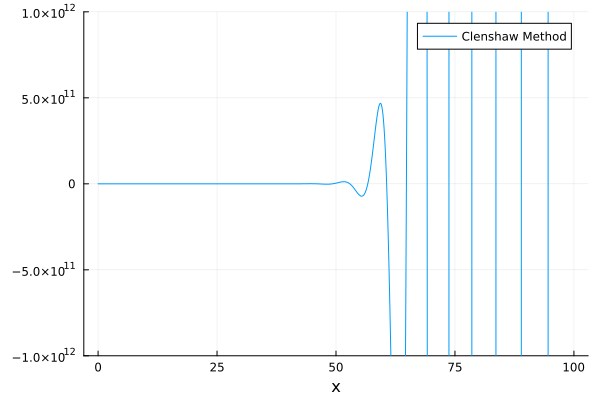

In [28]:
x_min_laguerre = 0
x_max_laguerre = 100
x_range_laguerre = range(x_min_laguerre, x_max_laguerre, length=1000)

poly_num = 50

#display(LaguerrePolynomials[1](5,2.0))
#display(LaguerrePolynomials[1](5,2.0).(collect(x_range_laguerre)))
y1 = LaguerrePolynomials[1](poly_num,2.0).(collect(x_range_laguerre))
#display((x->LaguerrePolynomials[6](5,2.0,x)).(collect(x_range_laguerre)))
y2 = (x->LaguerrePolynomials[6](poly_num,2.0,x)).(collect(x_range_laguerre))

plt = plot(collect(x_range_laguerre), y1, label="Polynomial Method", xlabel="x")
plot!(plt, collect(x_range_laguerre), y2, label="Clenshaw Method")
display(plt)

#clenslaw_pol = x->LaguerrePolynomials[6](5,2.0,x)
#display(clenslaw_pol)

#plot(collect(x_range_laguerre), y2, label="Clenshaw Method", xlabel="x", yrange =(-1000000000000.0,1000000000000.0))



In [83]:
function nPolynomialEigenDataThree_from_clenshaw_roots(poly::Tuple, n::Int, α::Float64) # Converting from BigFloat to Float64 to use eigen
    if poly == HermitePolynomials
        x_range = range(-sqrt(2*n+1),sqrt(2*n+1),length=10000)
    elseif poly == LaguerrePolynomials
        x_range = range(0,4*n+2*α+2,length=10000)
    elseif poly == GegenbauerPolynomials
        x_range = range(-1,1,length=10000)
    else
        println("Unknown polynomial in use, please input the range in which the roots are found")
    end
    #println(x_range)
        
    r = find_roots_clenshaw(poly, n, α, collect(x_range))
    length(r) == n || @warn "Expected $n roots, found $(length(r))"
    
    # --- step 5: build the eigenvector matrix in BigFloat
    ev = zeros(BigFloat, n, length(r))
    for k in 0:n-1
        p_k    = x->poly[6](k, α, x)
        norm_k = BigFloat(poly[2](k, α)) # your normalisation → BigFloat
        for (j, xj) in enumerate(r)
            ev[k+1, j] = norm_k * p_k(Float64(xj))
        end
    end
    
    # --- step 6: normalise each column
    for j in 1:size(ev,2)
        col = ev[:,j]
        ev[:,j] .= col ./ norm(col)
    end
    
    return (r, ev)
end

setprecision(1024)
n2 = 200
alpha2 = 2.0

#nPolynomialEigenDataThree_from_clenshaw_roots(HermitePolynomials, 5, 2.0)
clen_roots, clen_eigenvectors = nPolynomialEigenDataThree_from_clenshaw_roots(LaguerrePolynomials, n2+1, alpha2)
#nPolynomialEigenDataThree_from_clenshaw_roots(GegenbauerPolynomials, 5, 2.0)
old_roots, old_eigenvectors = nPolynomialEigenDataThree2(LaguerrePolynomials, n2, alpha2)

#display(old_eigenvectors)
#display(clen_eigenvectors)

#display(clen_roots)
#display(old_roots)

display(clen_roots.-old_roots)
#display(maximum(abs.(clen_roots.-old_roots)))
#display(chop_matrix(clen_roots.-old_roots,1e-9))

display(chop_matrix(clen_eigenvectors.-old_eigenvectors))
#display(chop_matrix(clen_eigenvectors.-old_eigenvectors,1e-9))

201-element Vector{BigFloat}:
  1.9706458687096528592519462108612060546875e-15
 -1.8041124150158793781884014606475830078125e-15
 -4.1355807667287081130780279636383056640625e-15
 -2.720046410331633524037897586822509765625e-15
 -1.5543122344752191565930843353271484375e-15
 -1.22124532708767219446599483489990234375e-15
 -2.10942374678779742680490016937255859375e-15
 -2.220446049250313080847263336181640625e-15
  2.220446049250313080847263336181640625e-16
 -1.5543122344752191565930843353271484375e-15
  0.0
 -2.4424906541753443889319896697998046875e-15
  0.0
  ⋮
  0.0
 -1.136868377216160297393798828125e-13
  2.27373675443232059478759765625e-13
  1.136868377216160297393798828125e-13
  1.136868377216160297393798828125e-13
  3.410605131648480892181396484375e-13
 -2.27373675443232059478759765625e-13
  0.0
  5.684341886080801486968994140625e-13
  3.410605131648480892181396484375e-13
 -2.27373675443232059478759765625e-13
  7.958078640513122081756591796875e-13

201×201 Matrix{BigFloat}:
 -2.9537e-17   -2.07654e-16  -8.86102e-16  …   0.0           0.0
 -6.05854e-17  -3.48161e-16  -1.40671e-15      0.0           0.0
 -8.78812e-17  -4.34595e-16  -1.74595e-15      0.0           0.0
 -9.25956e-17  -4.36325e-16  -1.81986e-15      0.0           0.0
 -1.48599e-16  -5.60819e-16  -2.07379e-15      0.0           0.0
 -1.7144e-16   -5.64854e-16  -2.0557e-15   …   0.0           0.0
 -1.72781e-16  -4.67048e-16  -1.81425e-15      0.0           0.0
 -1.98422e-16  -4.37552e-16  -1.6199e-15       0.0           0.0
 -2.60889e-16  -4.63383e-16  -1.48815e-15      0.0           0.0
 -2.75519e-16  -3.53997e-16  -1.1105e-15       0.0           0.0
 -3.54466e-16  -3.857e-16    -9.47709e-16  …   0.0           0.0
 -4.32391e-16  -3.9642e-16   -7.65529e-16      0.0           0.0
 -4.95996e-16  -3.65612e-16  -4.94566e-16      0.0           0.0
  ⋮                                        ⋱                 ⋮
  2.08857e-15  -2.07324e-15   1.10502e-15      4.497e-15     2.867

In [70]:
println(LaguerrePolynomials[1](5,2.0)(1.0))
println(LaguerrePolynomials[6](5,2.0,1.0))
(x->LaguerrePolynomials[6](5,2.0,x)).(1.0)

0.283333333333326109
0.283333333333333048


0.283333333333333048

In [74]:
function Hermitecn(n::Int)
    return sqrt(n/2)
end

function Gegenbauercn(n::Int, α::Real)
    return 1/2*sqrt(n(n+2*α-1)/((n+α-1)(n+α)))
end

function Lagcn(n::Int, α::Real)
    return -sqrt(n * (n + α))
end

function Lagbn(n::Int, α::Real)
    return 2n + α + 1
end

function phisLa_vector(i::Int, α::Real, xi::Real)
    T = promote_type(typeof(xi), typeof(α), Float64)
    αT = T(α)
    xiT = T(xi)

    φ = Vector{T}(undef, i + 1)

    # base cases
    φ[1] = one(T)
    if i >= 1
        φ[2] = ((xiT - Lagbn(0, αT)) * φ[1]) / Lagcn(1, αT)
    end

    # recurrence
    for n in 2:i
        cn   = Lagcn(n, αT)
        bn_1 = Lagbn(n - 1, αT)
        cn_1 = Lagcn(n - 1, αT)

        φ[n + 1] = (xiT * φ[n] - bn_1 * φ[n] - cn_1 * φ[n - 1]) / cn
    end

    return φ
end

function normalisedPhiLa(i::Int, α::Real, xi::Real)
    φ = phisLa_vector(i, α, xi)
    return φ ./ norm(φ)
end

function phisHermite_vector(i::Int, α::Real, xi::Real)
    T = promote_type(typeof(xi), typeof(α), Float64)
    αT = T(α)
    xiT = T(xi)

    φ = Vector{T}(undef, i + 1)

    # base cases
    φ[1] = one(T)
    if i >= 1
        φ[2] = (xiT * φ[1]) / Hermitecn(1, αT)
    end

    # recurrence
    for n in 2:i
        cn   = Hermitecn(n, αT)
        cn_1 = Hermitecn(n - 1, αT)

        φ[n + 1] = (xiT * φ[n] - cn_1 * φ[n - 1]) / cn
    end

    return φ
end

function normalisedPhiHermite(i::Int, α::Real, xi::Real)
    φ = phisHermite_vector(i, α, xi)
    return φ ./ norm(φ)
end

function phisGegen_vector(i::Int, α::Real, xi::Real)
    T = promote_type(typeof(xi), typeof(α), Float64)
    αT = T(α)
    xiT = T(xi)

    φ = Vector{T}(undef, i + 1)

    # base cases
    φ[1] = one(T)
    if i >= 1
        φ[2] = (xiT * φ[1]) / Gegenbauercn(1, αT)
    end

    # recurrence
    for n in 2:i
        cn   = Gegenbauercn(n, αT)
        cn_1 = Gegenbauercn(n - 1, αT)

        φ[n + 1] = (xiT * φ[n] - cn_1 * φ[n - 1]) / cn
    end

    return φ
end

function normalisedPhiGegen(i::Int, α::Real, xi::Real)
    φ = phisGegen_vector(i, α, xi)
    return φ ./ norm(φ)
end

normalisedPhiLa (generic function with 1 method)

In [84]:
function nPolynomialEigenDataThree_from_clenshaw_roots2(poly::Tuple, n::Int, α::Float64) # Converting from BigFloat to Float64 to use eigen
    if poly == HermitePolynomials
        x_range = range(-sqrt(2*n+1),sqrt(2*n+1),length=10000)
    elseif poly == LaguerrePolynomials
        x_range = range(0,4*n+2*α+2,length=10000)
    elseif poly == GegenbauerPolynomials
        x_range = range(-1,1,length=10000)
    else
        println("Unknown polynomial in use, please input the range in which the roots are found")
    end
    #println(x_range)
        
    r = find_roots_clenshaw(poly, n, α, collect(x_range))
    length(r) == n || @warn "Expected $n roots, found $(length(r))"
    
    # eigenvector matrix: one column per root
    ev = zeros(BigFloat, n, length(r))

    for (j, xj) in enumerate(r)
        # build the vector using the recurrence
        
        if poly == HermitePolynomials
            φ = normalisedPhiHermite(n - 1, α, xj)
        elseif poly == LaguerrePolynomials
            φ = normalisedPhiLa(n - 1, α, xj)
        elseif poly == GegenbauerPolynomials
            φ = normalisedPhiGegen(n - 1, α, xj)
        else
            println("Unknown polynomial in use, please input the recurrence relation")
        end

        # store as a column
        ev[:, j] = BigFloat.(φ)
    end
    
    return (r, ev)
end

n2 = 200
alpha2 = 2.0

#nPolynomialEigenDataThree_from_clenshaw_roots2(HermitePolynomials, 5, 2.0)
clen_roots, clen_eigenvectors = nPolynomialEigenDataThree_from_clenshaw_roots2(LaguerrePolynomials, n2+1, alpha2)
#nPolynomialEigenDataThree_from_clenshaw_roots2(GegenbauerPolynomials, 5, 2.0)
old_roots, old_eigenvectors = nPolynomialEigenDataThree2(LaguerrePolynomials, n2, alpha2)

#display(old_eigenvectors)
display(clen_eigenvectors)

#display(clen_roots)
#display(old_roots)

display(clen_roots.-old_roots)
#display(maximum(abs.(clen_roots.-old_roots)))
#display(chop_matrix(clen_roots.-old_roots,1e-9))

display(chop_matrix(clen_eigenvectors.-old_eigenvectors))
#display(chop_matrix(clen_eigenvectors.-old_eigenvectors,1e-9))

201×201 Matrix{BigFloat}:
 0.00468663    0.0153315   0.0327894   …   2.80581e-160   1.08327e-165
 0.00802938    0.0257806   0.053637       -1.21076e-157  -4.83265e-163
 0.0112317     0.0353883   0.0715771       3.19087e-155   1.3168e-160
 0.0143418     0.0443337   0.0871161      -6.12475e-153  -2.6135e-158
 0.0173728     0.0526778   0.100491        9.26898e-151   4.09005e-156
 0.0203302     0.0604552   0.111877    …  -1.15842e-148  -5.28646e-154
 0.0232169     0.0676919   0.121422        1.23291e-146   5.81927e-152
 0.0260349     0.0744101   0.129261       -1.14223e-144  -5.57664e-150
 0.0287858     0.0806298   0.135521        9.36498e-143   4.72985e-148
 0.0314706     0.0863698   0.140319       -6.88316e-141  -3.59658e-146
 0.0340906     0.0916481   0.143768    …   4.58238e-139   2.47739e-144
 0.0366466     0.0964819   0.145972       -2.78681e-137  -1.55903e-142
 0.0391397     0.100888    0.147032        1.55927e-135   9.02719e-141
 ⋮                                     ⋱             

201-element Vector{BigFloat}:
  1.9706458687096528592519462108612060546875e-15
 -1.8041124150158793781884014606475830078125e-15
 -4.1355807667287081130780279636383056640625e-15
 -2.720046410331633524037897586822509765625e-15
 -1.5543122344752191565930843353271484375e-15
 -1.22124532708767219446599483489990234375e-15
 -2.10942374678779742680490016937255859375e-15
 -2.220446049250313080847263336181640625e-15
  2.220446049250313080847263336181640625e-16
 -1.5543122344752191565930843353271484375e-15
  0.0
 -2.4424906541753443889319896697998046875e-15
  0.0
  ⋮
  0.0
 -1.136868377216160297393798828125e-13
  2.27373675443232059478759765625e-13
  1.136868377216160297393798828125e-13
  1.136868377216160297393798828125e-13
  3.410605131648480892181396484375e-13
 -2.27373675443232059478759765625e-13
  0.0
  5.684341886080801486968994140625e-13
  3.410605131648480892181396484375e-13
 -2.27373675443232059478759765625e-13
  7.958078640513122081756591796875e-13

201×201 Matrix{BigFloat}:
 -2.95202e-17  -2.06954e-16  -8.88255e-16  …   0.0           0.0
 -6.05753e-17  -3.47722e-16  -1.40813e-15      0.0           0.0
 -8.78739e-17  -4.3426e-16   -1.74705e-15      0.0           0.0
 -9.25898e-17  -4.36048e-16  -1.82078e-15      0.0           0.0
 -1.48594e-16  -5.6058e-16   -2.07457e-15      0.0           0.0
 -1.71436e-16  -5.64643e-16  -2.05637e-15  …   0.0           0.0
 -1.72777e-16  -4.66858e-16  -1.81482e-15      0.0           0.0
 -1.98418e-16  -4.3738e-16   -1.62039e-15      0.0           0.0
 -2.60885e-16  -4.63226e-16  -1.48855e-15      0.0           0.0
 -2.75516e-16  -3.53853e-16  -1.11083e-15      0.0           0.0
 -3.54463e-16  -3.85568e-16  -9.47967e-16  …   0.0           0.0
 -4.32389e-16  -3.96299e-16  -7.65721e-16      0.0           0.0
 -4.95993e-16  -3.65501e-16  -4.94696e-16      0.0           0.0
  ⋮                                        ⋱                 ⋮
  2.08857e-15  -2.07318e-15   1.10531e-15      4.497e-15     2.867

In [ ]:
# ------------------------------------------------------------------------------
# Example Usage
# ------------------------------------------------------------------------------
setprecision(53) # Float64
#setprecision(256)
#setprecision(1024)

# Define some sample Vcs dictionaries for different models:
Vcs_SHO = Dict(:β => 1.0)
Vcs_shiftedSHO = Dict(:β => 1.5)             # Shifted SHO uses β.
Vcs_DoubleWell = Dict(:β => 1.5, :c2 => 7.0)   # Double Well uses β and c2.
Vcs_HcsHydrogen = Dict(:α => 4.0, :β => 2.0)                # Hydrogen uses α.
Vcs_HcsHydrogenCoulomb = Dict(:α => 2.0, :β => 1.0)
Vcs_HcsGriffiths = Dict(:α => 2.0, :F_0 => 1*10^5, :β => 750, :m => 750) # α= 2l+2
Vcs_PoschlTeller = Dict(:λ => 10.0, :β => 1)
Vcs_Myo = Dict(:α => 2.0, :β => 1)
Vcs_KorschGluck = Dict(:λ => 0.1, :β => 1, :J => 0.8)
Vcs_KorschGluckComplexScaled = Dict(:λ => 0.1, :β => 1, :J => 0.8, :θ => pi/4)
Vcs_KorschGluckStepFunction = Dict(:λ => 0.1, :β => 1, :J => 0.8, :A => 2, :L => 7)
Vcs_KorschGluckTaylor = Dict(:λ => 0.1, :β => 1, :J => 0.8, :taylor_order => 6)
Vcs_InfiniteWell = Dict(:β => 1.0, :α => 2.0)    
Vcs_HarmonicOscillatorin3DplusGriffiths = Dict(:α => 0.5, :F_0 => 1*10^5, :β => 750, :m => 750) # α=l+1/2
Vcs_HarmonicOscillatorin3DplusCoulomb = Dict(:α => 0.5)
Vcs_HarmonicOscillatorin3D = Dict(:α => 0.5)
Vcs_CoulombplusLinear = Dict(:β => 1.0, :α => 2.0)  
Vcs_Charmonium = Dict(:β => 1.0, :α => 2.0, :A => 1/2.34^2, :kappa => 0.52, :mass => 1.84) # charmmass changed to mass for generalities
Vcs_Bottomonium = Dict(:β => 1.0, :α => 2.0, :A => 1/2.34^2, :kappa => 0.52, :mass => 5.18) # charmmass changed to mass for generalities
Vcs_cb = Dict(:β => 1.0, :α => 2.0, :A => 1/2.34^2, :kappa => 0.52, :massc => 1.84, :massb => 5.18) # charmmass changed to mass for generalities
#Vcs_FriedrichFigure27 = Dict(:α => 2.0, :m => 1.0, :hbar => 1.0)
Vcs_FriedrichFigure27 = Dict(:α => 2.0,:β => 1.0, :m => 0.5, :hbar => 1.0, :a => 20.0) 
Vcs_SquareWell3D = Dict(:α => 2.0,:β => 1.0, :L => 1.0, :U_0 => 1.0)

# Parameters
ifixed_matrix_size = 10          # Fixed matrix size (so matrix is (i+1)×(i+1))
imin_matrix_size = 8            # minimum matrix size
imax_matrix_size = 100           # maximum matrix size (set to avoid overflow)
number_of_eigs   = 8             # number of eigenvalues to extract

# Plot computed eigenvalues vs. matrix size for shifted SHO:
#plt1 = plot_lowest_eigenvalues(SHO, imin_matrix_size, imax_matrix_size, number_of_eigs, Vcs_SHO)
#plt1 = plot_lowest_eigenvalues(shiftedSHO, imin_matrix_size, imax_matrix_size, number_of_eigs, Vcs_shiftedSHO)
#plt1 = plot_lowest_eigenvalues(DoubleWell, imin_matrix_size, imax_matrix_size, number_of_eigs, Vcs_DoubleWell)
#plt1 = plot_lowest_eigenvalues(HcsHydrogen, imin_matrix_size, imax_matrix_size, number_of_eigs, Vcs_HcsHydrogen)
plt1 = plot_lowest_eigenvalues(Harmonic_Oscillator_3D_in_the_discrete_position_basis, imin_matrix_size, imax_matrix_size, number_of_eigs, Vcs_HcsHydrogen)
#plt1 = plot_lowest_eigenvalues(HcsHydrogenCoulomb, imin_matrix_size, imax_matrix_size, number_of_eigs, Vcs_HcsHydrogenCoulomb)
#plt1 = plot_lowest_eigenvalues(Coulomb_in_the_discrete_position_basis, imin_matrix_size, imax_matrix_size, number_of_eigs, Vcs_HcsHydrogenCoulomb)
#plt1 = plot_lowest_eigenvalues(HcsGriffiths, imin_matrix_size, imax_matrix_size, number_of_eigs, Vcs_HcsGriffiths)
#plt1 = plot_lowest_eigenvalues(Griffiths_in_the_discrete_position_basis, imin_matrix_size, imax_matrix_size, number_of_eigs, Vcs_HcsGriffiths)
#plt1 = plot_lowest_eigenvalues(PoschlTeller, imin_matrix_size, imax_matrix_size, number_of_eigs, Vcs_PoschlTeller)
#plt1 = plot_lowest_eigenvalues(KorschGluck, imin_matrix_size, imax_matrix_size, number_of_eigs, Vcs_KorschGluck)
#plt1 = plot_lowest_eigenvalues(KorschGluckwithBoundStates, imin_matrix_size, imax_matrix_size, number_of_eigs, Vcs_KorschGluckStepFunction)
#plt1 = plot_lowest_eigenvalues(InfiniteWell, imin_matrix_size, imax_matrix_size, number_of_eigs, Vcs_InfiniteWell)
#plt1 = plot_lowest_eigenvalues(HarmonicOscillatorin3DplusGriffiths, imin_matrix_size, imax_matrix_size, number_of_eigs, Vcs_HarmonicOscillatorin3DplusGriffiths)
#plt1 = plot_lowest_eigenvalues([HcsGriffiths, HarmonicOscillatorin3DplusGriffiths], ["x basis", "x^2 basis"], imin_matrix_size, imax_matrix_size, number_of_eigs, [Vcs_HcsGriffiths, Vcs_HarmonicOscillatorin3DplusGriffiths])
#plt1 = plot_lowest_eigenvalues([HcsGriffiths, Griffiths_in_the_discrete_position_basis], ["polynomial basis", "discrete position basis"], imin_matrix_size, imax_matrix_size, number_of_eigs, [Vcs_HcsGriffiths, Vcs_HcsGriffiths])
#plt1 = plot_lowest_eigenvalues(HarmonicOscillatorin3DplusCoulomb, imin_matrix_size, imax_matrix_size, number_of_eigs, Vcs_HarmonicOscillatorin3DplusCoulomb)
#plt1 = plot_lowest_eigenvalues([HcsHydrogenCoulomb, HarmonicOscillatorin3DplusCoulomb], ["x basis", "x^2 basis"], imin_matrix_size, imax_matrix_size, number_of_eigs, [Vcs_HcsHydrogenCoulomb, Vcs_HarmonicOscillatorin3DplusCoulomb])
#plt1 = plot_lowest_eigenvalues([HcsHydrogenCoulomb, Coulomb_in_the_discrete_position_basis], ["polynomial basis", "discrete position basis"], imin_matrix_size, imax_matrix_size, number_of_eigs, [Vcs_HcsHydrogenCoulomb, Vcs_HcsHydrogenCoulomb])
#plt1 = plot_lowest_eigenvalues(HarmonicOscillatorin3D, imin_matrix_size, imax_matrix_size, number_of_eigs, Vcs_HarmonicOscillatorin3D)
#plt1 = plot_lowest_eigenvalues([HcsHydrogen, HarmonicOscillatorin3D], ["x basis", "x^2 basis"], imin_matrix_size, imax_matrix_size, number_of_eigs, [Vcs_HcsHydrogen, Vcs_HarmonicOscillatorin3D])
#plt1 = plot_lowest_eigenvalues([HcsHydrogen, Harmonic_Oscillator_3D_in_the_discrete_position_basis], ["polynomial basis", "discrete position basis"], imin_matrix_size, imax_matrix_size, number_of_eigs, [Vcs_HcsHydrogen, Vcs_HcsHydrogen])
#plt1 = plot_lowest_eigenvalues(CoulombplusLinear, imin_matrix_size, imax_matrix_size, number_of_eigs, Vcs_CoulombplusLinear)
#plt1 = plot_lowest_eigenvalues(CoulombplusLinear_in_the_discrete_position_basis, imin_matrix_size, imax_matrix_size, number_of_eigs, Vcs_CoulombplusLinear)
#plt1 = plot_lowest_eigenvalues([CoulombplusLinear, CoulombplusLinear_in_the_discrete_position_basis], ["polynomial basis", "discrete position basis"], imin_matrix_size, imax_matrix_size, number_of_eigs, [Vcs_CoulombplusLinear, Vcs_CoulombplusLinear])
#plt1 = plot_lowest_eigenvalues([PoschlTeller, PoschlTellerwithTaylor, PoschlTellerwithTaylor2, PoschlTellerwithTaylor3, PoschlTellerwithTaylor4], ["Diagonalisation", "Taylor Series Order 2", "Taylor Series Order 6", "Taylor Series Order 10", "Taylor Series Order 14"], imin_matrix_size, imax_matrix_size, number_of_eigs, [Vcs_PoschlTeller, Vcs_PoschlTeller, Vcs_PoschlTeller, Vcs_PoschlTeller, Vcs_PoschlTeller])
#plt1 = plot_lowest_eigenvalues([KorschGluck, KorschGluckwithTaylor, KorschGluckwithTaylor2, KorschGluckwithTaylor3], ["Diagonalisation", "Taylor Series Order 4", "Taylor Series Order 8",  "Taylor Series Order 12"], imin_matrix_size, imax_matrix_size, number_of_eigs, [Vcs_KorschGluck, Vcs_KorschGluck, Vcs_KorschGluck, Vcs_KorschGluck])
#plt1 = plot_lowest_eigenvalues([KorschGluck, KorschGluckwithTaylor3], ["Diagonalisation", "Taylor Series Order 12"], imin_matrix_size, imax_matrix_size, number_of_eigs, [Vcs_KorschGluck, Vcs_KorschGluck])
#plt1 = plot_lowest_eigenvalues([KorschGluck, KorschGluckwithBoundStates], ["Korsch Gluck Potential", "Korsch Gluck with Step Function Potential"], imin_matrix_size, imax_matrix_size, number_of_eigs, [Vcs_KorschGluck, Vcs_KorschGluckStepFunction])
#plt1 = plot_lowest_eigenvalues(KorschGluckTaylor, imin_matrix_size, imax_matrix_size, number_of_eigs, Vcs_KorschGluckTaylor)
#plt1 = plot_lowest_eigenvalues([KorschGluck, KorschGluckTaylor], ["Diagonalisation", "Taylor Series Order 12"], imin_matrix_size, imax_matrix_size, number_of_eigs, [Vcs_KorschGluck, Vcs_KorschGluckTaylor])
#plt1 = plot_lowest_eigenvalues([KorschGluck, KorschGluckTaylor, KorschGluckwithTaylor3], ["Diagonalisation", "Taylor Series Order 12", "Manual Order 12"], imin_matrix_size, imax_matrix_size, number_of_eigs, [Vcs_KorschGluck, Vcs_KorschGluckTaylor, Vcs_KorschGluck])
#plt1 = plot_lowest_eigenvalues(Charmonium, imin_matrix_size, imax_matrix_size, number_of_eigs, Vcs_CoulombplusLinear)
#plt1 = plot_lowest_eigenvalues(FriedrichFigure27, imin_matrix_size, imax_matrix_size, number_of_eigs, Vcs_FriedrichFigure27)
#plt1 = plot_lowest_eigenvalues(SquareWell3D, imin_matrix_size, imax_matrix_size, number_of_eigs, Vcs_SquareWell3D)
display(plt1)

# Plot relative error vs. matrix size for Hydrogen (if true eigenvalue available):
#plt2 = plot_eigenvalue_ratio(SHO, imin_matrix_size, imax_matrix_size, number_of_eigs, Vcs_SHO)
#plt2 = plot_eigenvalue_ratio(shiftedSHO, imin_matrix_size, imax_matrix_size, number_of_eigs, Vcs_shiftedSHO)
#plt2 = plot_eigenvalue_ratio(DoubleWell, imin_matrix_size, imax_matrix_size, number_of_eigs, Vcs_DoubleWell)
#plt2 = plot_eigenvalue_ratio(PoschlTeller, imin_matrix_size, imax_matrix_size, number_of_eigs, Vcs_PoschlTeller)

#plt2 = plot_eigenvalue_ratio(HcsHydrogen, imin_matrix_size, imax_matrix_size, number_of_eigs, Vcs_HcsHydrogen)
#plt2 = plot_eigenvalue_ratio(Harmonic_Oscillator_3D_in_the_discrete_position_basis, imin_matrix_size, imax_matrix_size, number_of_eigs, Vcs_HcsHydrogen)
#plt2 = plot_eigenvalue_ratio(HcsHydrogenCoulomb, imin_matrix_size, imax_matrix_size, number_of_eigs, Vcs_HcsHydrogenCoulomb)
#plt2 = plot_eigenvalue_ratio(Coulomb_in_the_discrete_position_basis, imin_matrix_size, imax_matrix_size, number_of_eigs, Vcs_HcsHydrogenCoulomb)

#plt2 = plot_eigenvalue_ratio(InfiniteWell, imin_matrix_size, imax_matrix_size, number_of_eigs, Vcs_InfiniteWell)
#plt2 = plot_eigenvalue_ratio([PoschlTeller, PoschlTellerwithTaylor, PoschlTellerwithTaylor2, PoschlTellerwithTaylor3, PoschlTellerwithTaylor4], ["Diagonalisation", "Taylor Series Order 2", "Taylor Series Order 6", "Taylor Series Order 10", "Taylor Series Order 14"], imin_matrix_size, imax_matrix_size, number_of_eigs, [Vcs_PoschlTeller, Vcs_PoschlTeller, Vcs_PoschlTeller, Vcs_PoschlTeller, Vcs_PoschlTeller])
#plt2 = plot_eigenvalue_ratio([KorschGluck, KorschGluckwithTaylor, KorschGluckwithTaylor2, KorschGluckwithTaylor3], ["Diagonalisation", "Taylor Series Order 4", "Taylor Series Order 8",  "Taylor Series Order 12"], imin_matrix_size, imax_matrix_size, number_of_eigs, [Vcs_KorschGluck, Vcs_KorschGluck, Vcs_KorschGluck, Vcs_KorschGluck])
#display(plt2)

# Vary parameter :β in shifted SHO:
β_range = 0.05:0.1:5.0
#plt3 = plot_parameter_variation(SHO, :β, β_range, Vcs_shiftedSHO, ifixed_matrix_size, number_of_eigs)
#plt3 = plot_parameter_variation(shiftedSHO, :β, β_range, Vcs_shiftedSHO, ifixed_matrix_size, number_of_eigs)
#plt3 = plot_parameter_variation(PoschlTeller, :β, β_range, Vcs_PoschlTeller, ifixed_matrix_size, number_of_eigs)
#plt3 = plot_parameter_variation(DoubleWell, :β, β_range, Vcs_DoubleWell, ifixed_matrix_size, number_of_eigs)
#plt3 = plot_parameter_variation(KorschGluck, :β, β_range, Vcs_KorschGluck, ifixed_matrix_size, number_of_eigs)
#plt3 = plot_parameter_variation(InfiniteWell, :β, β_range, Vcs_InfiniteWell, ifixed_matrix_size, number_of_eigs)
#plt3 = plot_parameter_variation(Bottomonium, :β, β_range, Vcs_CoulombplusLinear, ifixed_matrix_size, number_of_eigs)
#display(plt3)

β_range = 10:10:1500
#plt3 = plot_parameter_variation(HcsGriffiths, :β, β_range, Vcs_HcsGriffiths, ifixed_matrix_size, number_of_eigs)
#display(plt3)

# Vary parameter :c2 in Double Well:
#c2_range = 1:0.1:10.0
#plt4 = plot_parameter_variation(DoubleWell, :c2, c2_range, Vcs_DoubleWell, ifixed_matrix_size, number_of_eigs)
#display(plt4)

#x_range = -10:0.1:10
#x_range = -1:0.1:1
x_range = 0:0.1:200
#plt_wave = plot_wavefunctions(SHO, Vcs_SHO, HermitePolynomials, ifixed_matrix_size, x_range, [1,2,3])
#plt_wave = plot_wavefunctions(shiftedSHO, Vcs_shiftedSHO, HermitePolynomials, ifixed_matrix_size, x_range, [1,2,3])
#plt_wave = plot_wavefunctions(DoubleWell, Vcs_DoubleWell, HermitePolynomials, ifixed_matrix_size, x_range, [1,2])
#plt_wave = plot_wavefunctions(PoschlTeller, Vcs_PoschlTeller, HermitePolynomials, ifixed_matrix_size, x_range, [1,2])
#plt_wave = plot_wavefunctions(KorschGluck, Vcs_KorschGluck, HermitePolynomials, ifixed_matrix_size, x_range, [1,2,3])
#plt_wave = plot_wavefunctions(InfiniteWell, Vcs_InfiniteWell, GegenbauerPolynomials, ifixed_matrix_size, x_range, [1,2])
#plt_wave = plot_wavefunctions(HcsHydrogen, Vcs_HcsHydrogen, LaguerrePolynomials, ifixed_matrix_size, x_range, [1,2])
#plt_wave = plot_wavefunctions(Harmonic_Oscillator_3D_in_the_discrete_position_basis, Vcs_HcsHydrogen, LaguerrePolynomials, ifixed_matrix_size, x_range, [1,2])

#setprecision(1024)
#plt_wave = plot_wavefunctions(Myo, Vcs_Myo, LaguerrePolynomials, ifixed_matrix_size, x_range, [3])
#plt_wave = plot_wavefunctions(zeroPotential, Vcs_zeroPotential, LaguerrePolynomials, ifixed_matrix_size, x_range, [1])

#plt_wave = plot_wavefunctions(HcsHydrogenCoulomb, Vcs_HcsHydrogenCoulomb, LaguerrePolynomials, ifixed_matrix_size, x_range, [1,2])
#plt_wave = plot_wavefunctions(Coulomb_in_the_discrete_position_basis, Vcs_HcsHydrogenCoulomb, LaguerrePolynomials, ifixed_matrix_size, x_range, [1,2])
#plt_wave = plot_wavefunctions(CoulombplusLinear, Vcs_CoulombplusLinear, LaguerrePolynomials, ifixed_matrix_size, x_range, [1,2])
#plt_wave = plot_wavefunctions(CoulombplusLinear_in_the_discrete_position_basis, Vcs_CoulombplusLinear, LaguerrePolynomials, ifixed_matrix_size, x_range, [1,2])

#plt_wave = plot_wavefunctions(HcsGriffiths, Vcs_HcsGriffiths, LaguerrePolynomials, ifixed_matrix_size, x_range, [1,2])
#plt_wave = plot_wavefunctions(Griffiths_in_the_discrete_position_basis, Vcs_HcsGriffiths, LaguerrePolynomials, ifixed_matrix_size, x_range, [1,2])

#plt_wave = plot_wavefunctions_with_vectors_in_the_discrete_position_basis(Harmonic_Oscillator_3D_in_the_discrete_position_basis, Vcs_HcsHydrogen, LaguerrePolynomials, ifixed_matrix_size, x_range, [1,2])

#plt_wave = plot_wavefunctions(Charmonium, Vcs_CoulombplusLinear, LaguerrePolynomials, ifixed_matrix_size, x_range, [1,2])
#display(plt_wave)

#heigensystem(KorschGluck, 100, Dict(:λ => 0.1, :β => 1, :J => 0.8, :A => 1, :L => 20))